# Credit Score Classification - Machine Learning Project

**Author:** Davide De Blasio  
**Date:** November 19, 2025

---

## Project Overview

This project performs comprehensive data analysis and preprocessing on a credit score classification dataset. The workflow follows a systematic approach from data acquisition through to model-ready features, including:

- Exploratory Data Analysis (EDA)
- Data Cleaning & Missing Value Treatment
- Feature Engineering
- Statistical Testing & Feature Selection
- Outlier Detection & Treatment
- Feature Encoding
- Preprocessing for Machine Learning

**Target Variable:** Credit Score (Poor, Standard, Good)

---

# === 1. ENVIRONMENT SETUP ===

In [912]:
# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Statistical testing
from scipy import stats
import pingouin as pg

# Preprocessing and modeling
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# === 2. DATA ACQUISITION ===

In [913]:
# Download the dataset from Kaggle
path = kagglehub.dataset_download("parisrohan/credit-score-classification")

# Load the CSV files in data
df = pd.read_csv(path + "/train.csv", low_memory=False)

print(f"\nDataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset Dimensions: 100000 rows × 28 columns


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


# === 3. EXPLORATORY DATA ANALYSIS (EDA) ===

## 3.1 Dataset Overview

In [914]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score    

In [915]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [916]:
# Unique values per column
print("Unique Values per Column:")
print(df.nunique())

Unique Values per Column:
ID                          100000
Customer_ID                  12500
Month                            8
Name                         10139
Age                           1788
SSN                          12501
Occupation                      16
Annual_Income                18940
Monthly_Inhand_Salary        13235
Num_Bank_Accounts              943
Num_Credit_Card               1179
Interest_Rate                 1750
Num_of_Loan                    434
Type_of_Loan                  6260
Delay_from_due_date             73
Num_of_Delayed_Payment         749
Changed_Credit_Limit          4384
Num_Credit_Inquiries          1223
Credit_Mix                       4
Outstanding_Debt             13178
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          14950
Amount_invested_monthly      91049
Payment_Behaviour                7
Monthly_Balance              98792
Credit_Score                 

In [917]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


## 3.2 Feature Descriptions

**Key Features:**
- **ID**: Unique identification of an entry
- **Customer_ID**: Unique identification of a person
- **Month**: Month of the year
- **Name**: Name of a person
- **Age**: Age of the person
- **SSN**: Social security number
- **Occupation**: Occupation of the person
- **Annual_Income**: Annual income of the person
- **Monthly_Inhand_Salary**: Monthly base salary
- **Num_Bank_Accounts**: Number of bank accounts held
- **Num_Credit_Card**: Number of credit cards held
- **Interest_Rate**: Interest rate on credit card
- **Num_of_Loan**: Number of loans taken
- **Type_of_Loan**: Types of loans taken
- **Delay_from_due_date**: Average days delayed from payment date
- **Num_of_Delayed_Payment**: Average number of payments delayed
- **Changed_Credit_Limit**: Percentage change in credit card limit
- **Num_Credit_Inquiries**: Number of credit card inquiries
- **Credit_Mix**: Classification of mix of credits
- **Outstanding_Debt**: Remaining debt to be paid (USD)
- **Credit_Utilization_Ratio**: Utilization ratio of credit card
- **Credit_History_Age**: Age of credit history
- **Payment_of_Min_Amount**: Whether minimum amount was paid
- **Total_EMI_per_month**: Monthly EMI payments (USD)
- **Amount_invested_monthly**: Monthly investment amount (USD)
- **Payment_Behaviour**: Payment behavior of customer
- **Monthly_Balance**: Monthly balance amount (USD)
- **Credit_Score**: Bracket of credit score (Poor, Standard, Good) - **TARGET**

## 3.3 Missing Values Analysis

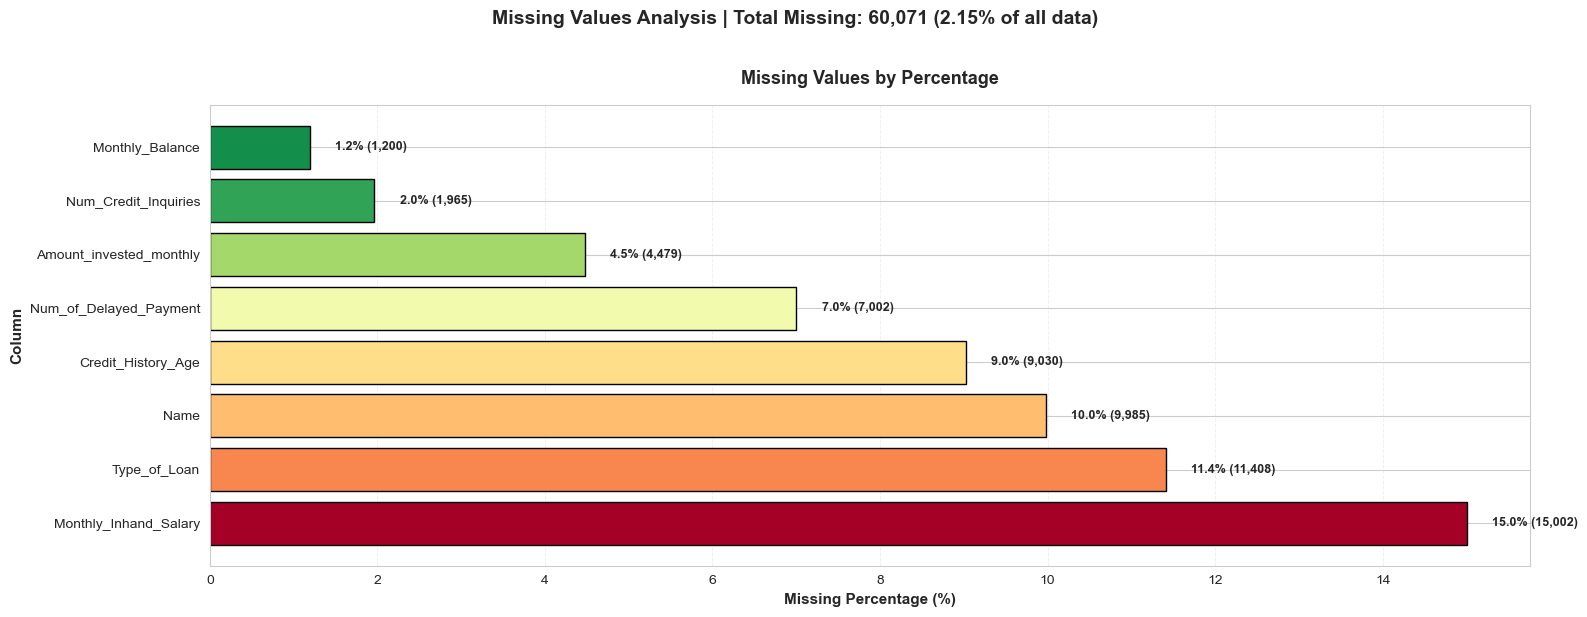


Missing Values Summary:
Total missing values: 60,071
Percentage of total data: 2.15%
Columns with missing values: 8 out of 28


In [918]:
# Create a comprehensive missing values visualization
fig, ax1 = plt.subplots(1,1, figsize=(16, 6))

# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Filter columns with missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

# Horizontal bar chart with percentages
colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, 
                edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values by Percentage', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

# Add percentage labels on bars
for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}% ({int(count):,})',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Add summary statistics
total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total Missing: {int(total_missing):,} ({overall_pct:.2f}% of all data)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Display summary
print("\nMissing Values Summary:")
print(f"Total missing values: {int(total_missing):,}")
print(f"Percentage of total data: {overall_pct:.2f}%")
print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")

## 3.4 Statistical Summaries

In [919]:
# Statistical summary for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [920]:
# Statistical summary for categorical features
df.describe(exclude=np.number).T

,count,unique,top,freq
ID,100000,100000,0x1602,1
Customer_ID,100000,12500,CUS_0xd40,8
Month,100000,8,January,12500
Name,90015,10139,Langep,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,36585.12,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


## 3.5 Target Variable Distribution

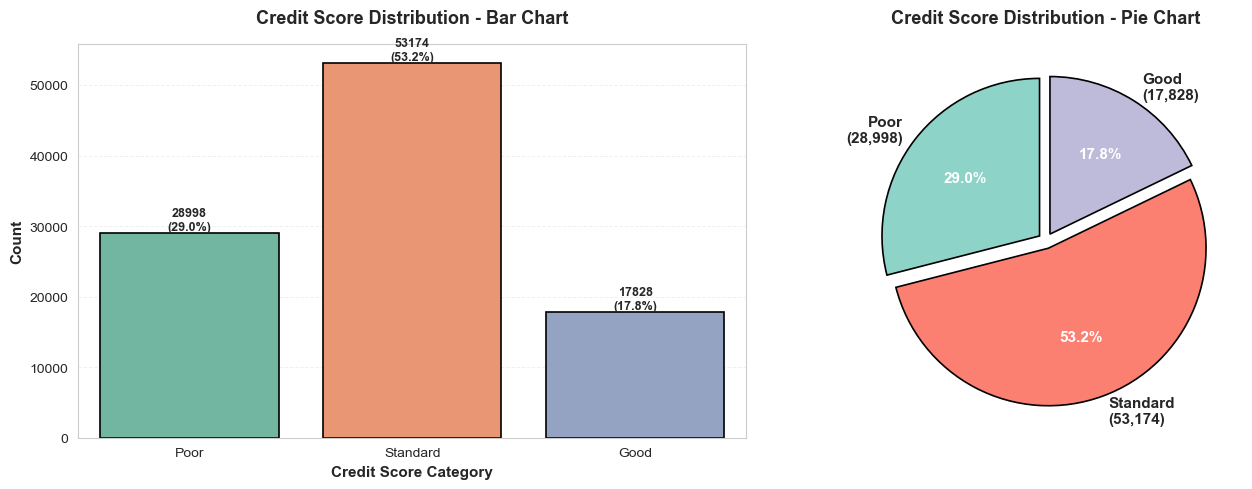


Normalized Credit Score Distribution:
Credit_Score
Good        0.17828
Poor        0.28998
Standard    0.53174
Name: proportion, dtype: float64


In [921]:
# Create a comprehensive visualization for Credit Score distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Get value counts in the correct order
credit_order = ['Poor', 'Standard', 'Good']
credit_counts = df['Credit_Score'].value_counts()[credit_order]
total = len(df['Credit_Score'])

# Left plot: Bar chart
sns.countplot(data=df, x='Credit_Score', ax=ax1, palette='Set2', 
              edgecolor='black', linewidth=1.2, order=credit_order)

ax1.set_title('Credit Score Distribution - Bar Chart', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Credit Score Category', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

# Add combined count and percentage labels on bars
for patch in ax1.patches:
    height = patch.get_height()
    percentage = (height / total) * 100
    ax1.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Right plot: Pie chart
colors = ['#8dd3c7', '#fb8072', '#bebada']
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = ax2.pie(credit_counts, labels=credit_order, autopct='%1.1f%%',
                                     colors=colors, explode=explode, startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})

# Enhance autopct text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Add count to labels
for i, (label, count) in enumerate(zip(texts, credit_counts)):
    label.set_fontsize(11)
    label.set_fontweight('bold')
    label.set_text(f'{label.get_text()}\n({count:,})')

ax2.set_title('Credit Score Distribution - Pie Chart', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Display normalized value counts
print("\nNormalized Credit Score Distribution:")
print(df['Credit_Score'].value_counts(normalize=True).sort_index())

## 3.6 Categorical Features Distribution

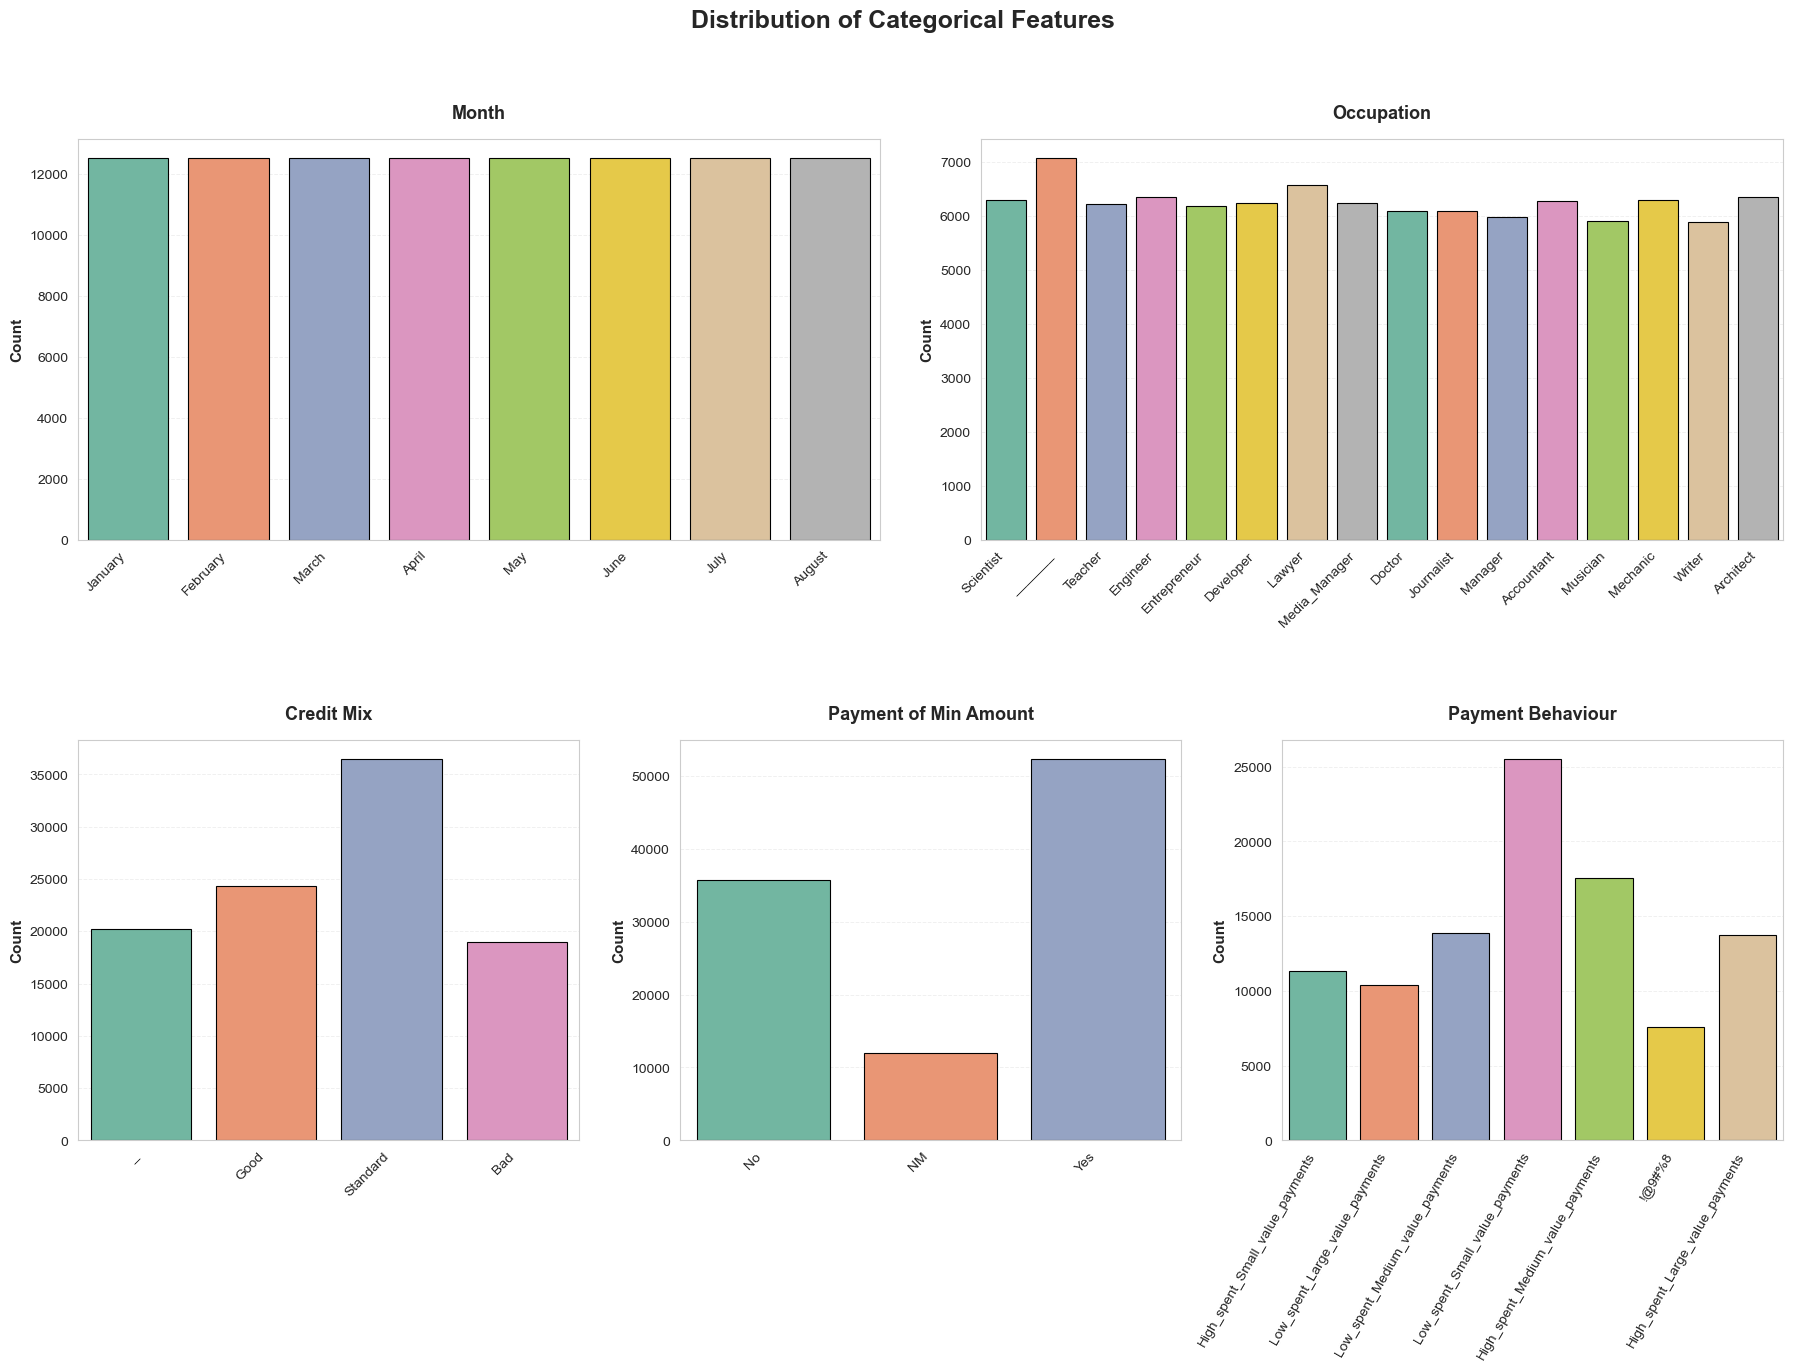

In [922]:
# Create a single figure with subplots for categorical variables
columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

fig = plt.figure(figsize=(22, 13))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.5)

# Row 1: 2 plots centered
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Row 2: 3 plots
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes_list = [ax1, ax2, ax3, ax4, ax5]

fig.suptitle('Distribution of Categorical Features', fontsize=18, fontweight='bold', y=0.98)

for idx, col in enumerate(columns):
    ax = axes_list[idx]
    sns.countplot(data=df, x=col, ax=ax, palette='Set2', edgecolor='black', linewidth=0.8)
    ax.set_title(f'{col.replace("_", " ")}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    
    # Special handling for Payment_Behaviour with long labels
    if col == 'Payment_Behaviour':
        ax.tick_params(axis='x', rotation=60, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
            label.set_fontweight('medium')
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 3.7 Numerical Features Distribution

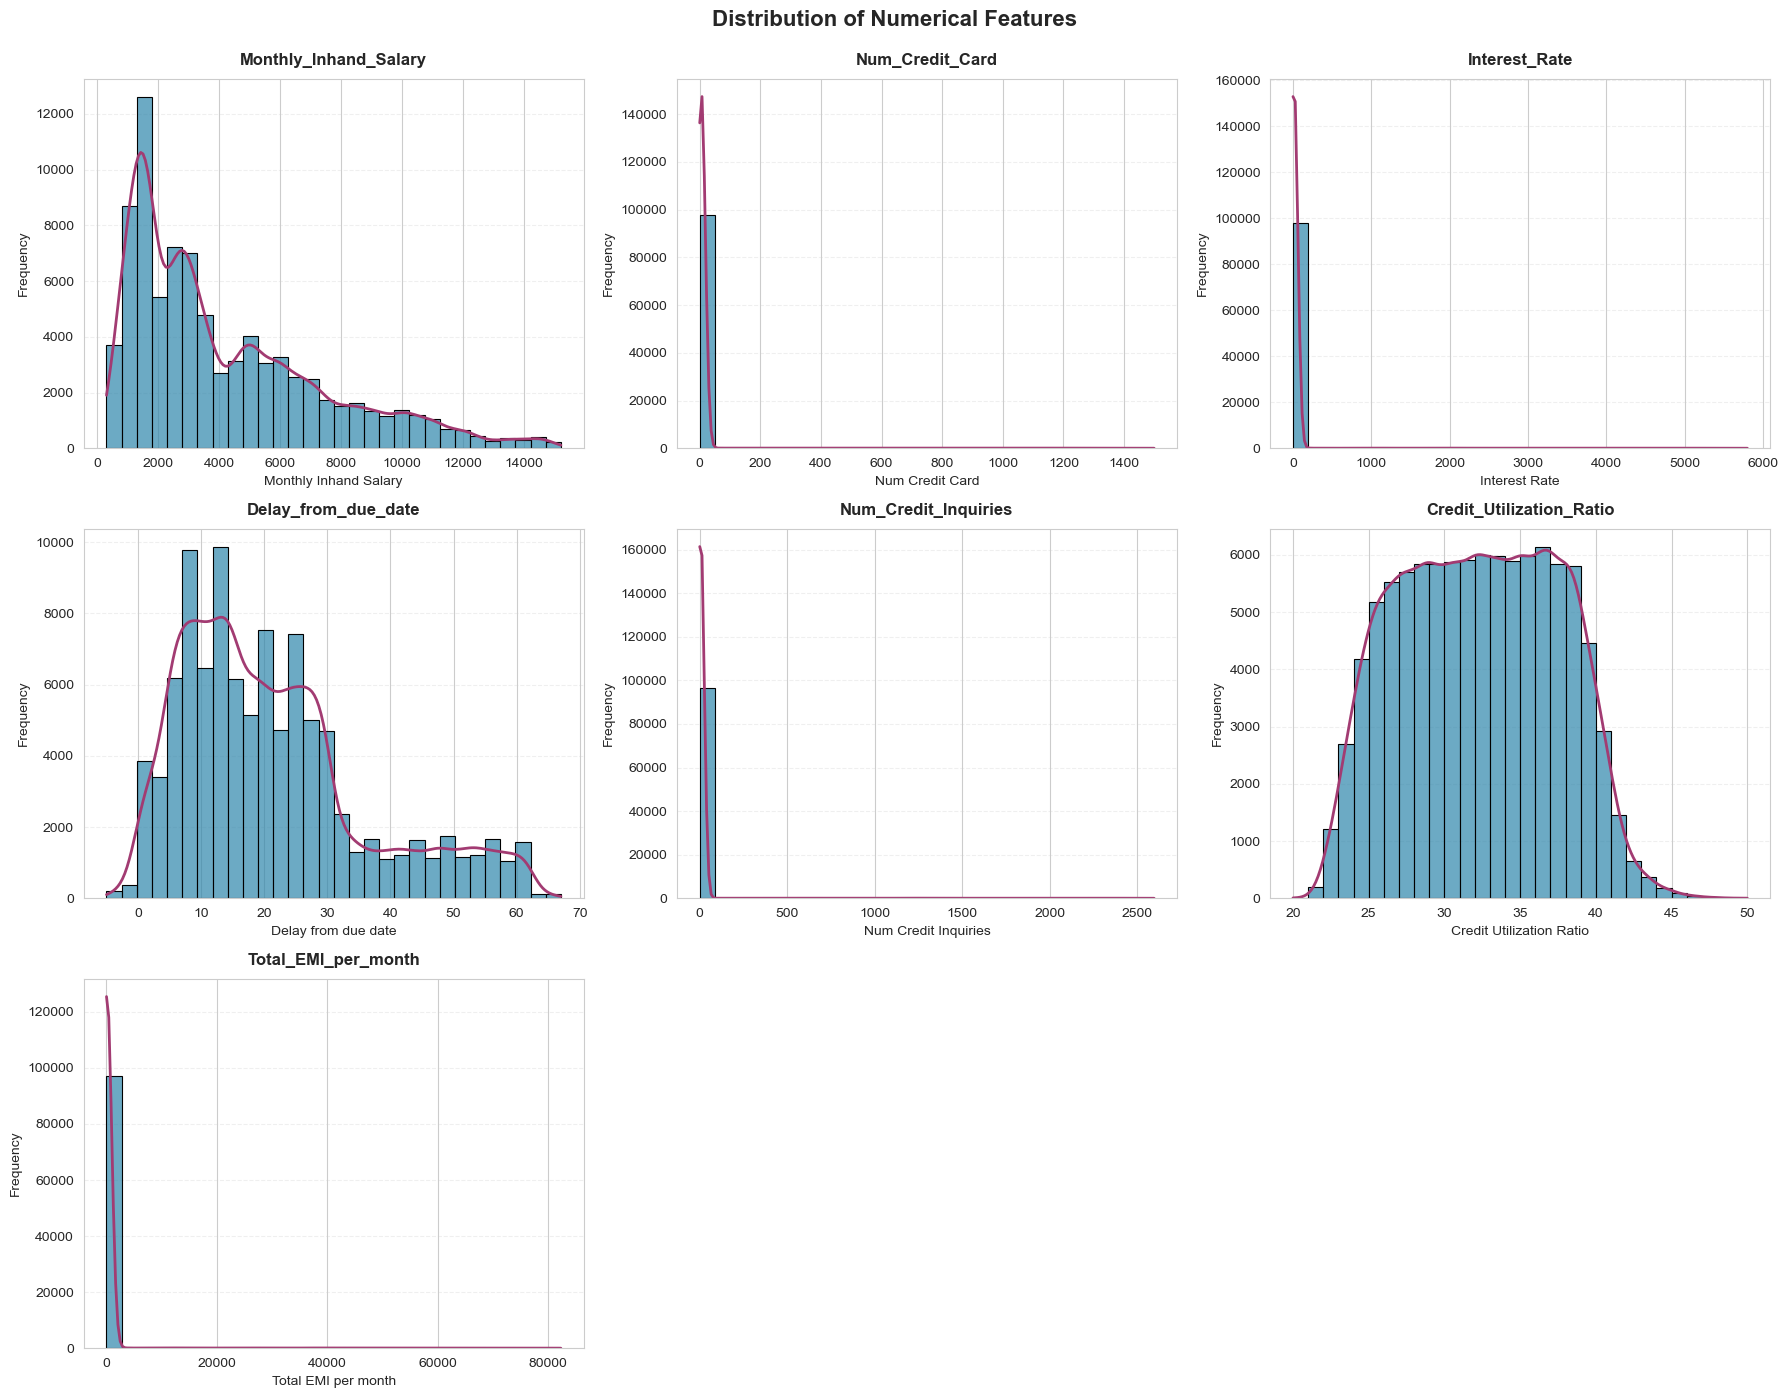

In [923]:
# Create a single figure with subplots for numerical variables
columns = ['Monthly_Inhand_Salary', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 
           'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for idx, col in enumerate(columns):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='#2E86AB', 
                 edgecolor='black', linewidth=0.8, bins=30, alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel(col.replace('_', ' '), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Style KDE line
    for line in axes[idx].lines:
        line.set_color('#A23B72')
        line.set_linewidth(2)

# Hide the extra subplots
for idx in range(len(columns), 9):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3.8 Type of Loan Analysis

In [924]:
# Display top 10 Type_of_Loan values
print("Type of Loan - Top 10 Values:")
df['Type_of_Loan'].value_counts().head(10)

Type of Loan - Top 10 Values:


Type_of_Loan
Not Specified                      1408
Credit-Builder Loan                1280
Personal Loan                      1272
Debt Consolidation Loan            1264
Student Loan                       1240
Payday Loan                        1200
Mortgage Loan                      1176
Auto Loan                          1152
Home Equity Loan                   1136
Personal Loan, and Student Loan     320
Name: count, dtype: int64

## 3.9 Initial Observations

**Key Findings from EDA:**
1. **ID, Name, SSN**: Not useful for prediction (should be dropped)
2. **Data Type Issues**: Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Amount_invested_monthly, Outstanding_Debt, Monthly_Balance are numerical but stored as categorical (need fixing)
3. **Placeholder Values**: Occupation and Credit_Mix have "__" values that need replacement
4. **Data Quality Issues**:
   - Data contains outliers
   - Num_Credit_Card has zeros
   - Num_Bank_Accounts contains negative values
5. **Feature Engineering Needed**:
   - Type_of_Loan needs to be split into multiple binary columns
   - Credit_History_Age format needs conversion to months
   - Payment_of_Min_Amount has 'NM' values
   - Payment_Behaviour and Credit_Mix need cleaning
6. **Target Imbalance**: Credit Score distribution is imbalanced
7. **Missing Data**: Significant missing values across multiple columns

# === 4. DATA CLEANING ===

## 4.1 Drop Irrelevant Columns

In [925]:
# Drop ID, Name, and SSN columns (not useful for prediction)
cols_to_drop = ['ID', 'Name', 'SSN']
df.drop(cols_to_drop, axis=1, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")

Dropped columns: ['ID', 'Name', 'SSN']
New shape: (100000, 25)


## 4.2 Fix Data Type Issues

In [926]:
# Remove underscores from numerical columns stored as strings and convert to float
cols_to_fix = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in cols_to_fix:
    df[col] = df[col].str.replace('_', '')
    try:
        df[col] = df[col].astype('float')
    except:
        continue

print("Fixed data types for numerical columns:")
df[cols_to_fix].info()

Fixed data types for numerical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  float64
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  float64
 3   Num_of_Delayed_Payment   92998 non-null   float64
 4   Changed_Credit_Limit     100000 non-null  object 
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  95521 non-null   float64
 7   Monthly_Balance          98800 non-null   float64
dtypes: float64(7), object(1)
memory usage: 6.1+ MB


In [927]:
# Fix Changed_Credit_Limit - replace empty strings with NaN
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('', np.nan)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype('float')

print("Fixed Changed_Credit_Limit column")

Fixed Changed_Credit_Limit column


In [928]:
# Verify fixes with descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


## 4.3 Handle Negative Values and Invalid Entries

In [929]:
# Replace negative values with NaN (invalid entries)
columns_to_fix = ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit']

df[columns_to_fix] = df[columns_to_fix].applymap(lambda x: np.nan if x < 0 else x)

print("Replaced negative values with NaN")
print("\nDescriptive statistics after fixing:")
df[cols_to_fix].describe().T

Replaced negative values with NaN

Descriptive statistics after fixing:


,count,mean,std,min,25%,50%,75%,max
Age,99114.0,1.161084e+02,6.868613e+02,1.400000e+01,25.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Num_of_Loan,96124.0,7.163622e+00,6.031492e+01,0.000000e+00,2.000000,3.000000,5.000000,1.496000e+03
Num_of_Delayed_Payment,92354.0,3.115052e+01,2.268022e+02,0.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,96323.0,1.059904e+01,6.639966e+00,0.000000e+00,5.570000,9.520000,15.010000,3.697000e+01
Outstanding_Debt,100000.0,1.426220e+03,1.155129e+03,2.300000e-01,566.072500,1166.155000,1945.962500,4.998070e+03
Amount_invested_monthly,95521.0,6.374130e+02,2.043319e+03,0.000000e+00,74.534002,135.925682,265.731733,1.000000e+04
Monthly_Balance,98800.0,-3.036437e+22,3.181295e+24,-3.333333e+26,270.092209,336.719190,470.220186,1.602041e+03


## 4.4 Initial Correlation Analysis

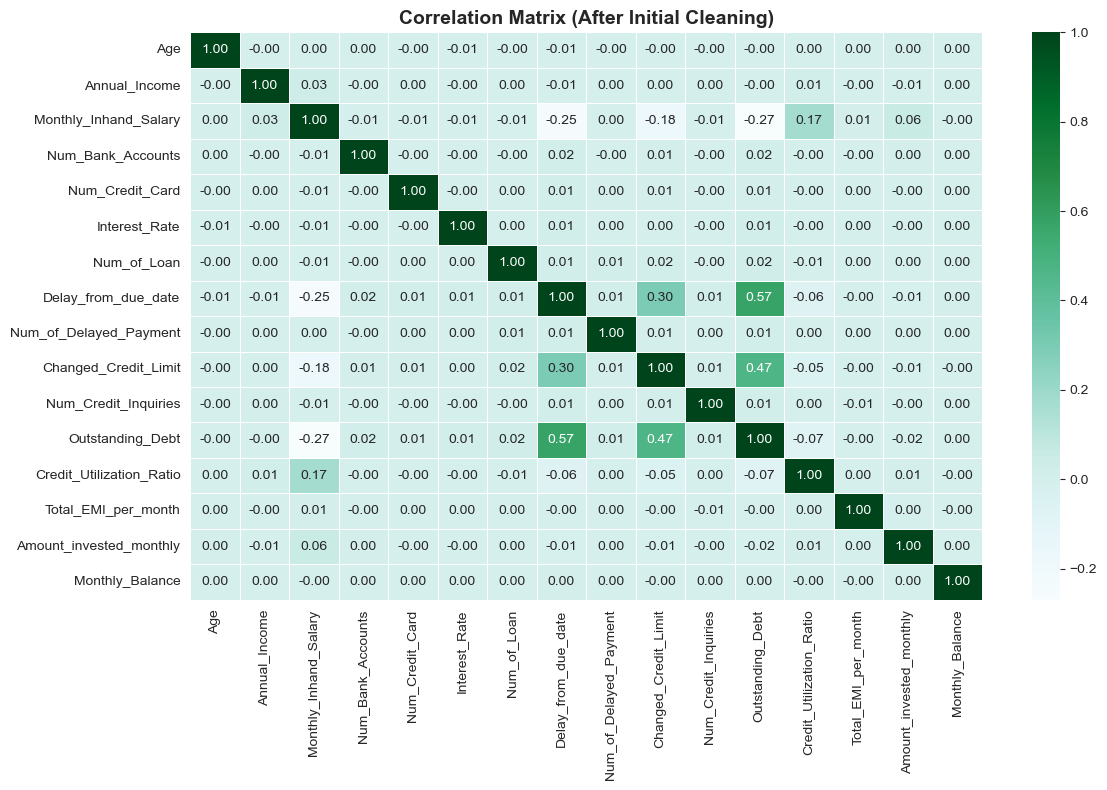

In [930]:
# Correlation matrix after initial cleaning
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix (After Initial Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.5 Categorical Data Examination

In [931]:
# Examine categorical features
data_categorical = df[df.select_dtypes(include=['object']).columns]
print("Categorical features:")
data_categorical.head()

Categorical features:


,Customer_ID,Month,Occupation,Type_of_Loan,Credit_Mix,Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,CUS_0xd40,January,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",_,22 Years and 1 Months,No,High_spent_Small_value_payments,Good
1,CUS_0xd40,February,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,NaN,No,Low_spent_Large_value_payments,Good
2,CUS_0xd40,March,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 3 Months,No,Low_spent_Medium_value_payments,Good
3,CUS_0xd40,April,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 4 Months,No,Low_spent_Small_value_payments,Good
4,CUS_0xd40,May,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 5 Months,No,High_spent_Medium_value_payments,Good


In [932]:
# Value counts for all categorical columns
for i in df.select_dtypes(include='object').columns.tolist():
    print(f'\n{i} value counts:')
    print(df[i].value_counts())
    print('-' * 50)


Customer_ID value counts:
Customer_ID
CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
             ..
CUS_0x2eb4    8
CUS_0x7863    8
CUS_0x9d89    8
CUS_0xc045    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64
--------------------------------------------------

Month value counts:
Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
--------------------------------------------------

Occupation value counts:
Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64
------------------------------

## 4.6 Feature-Specific Cleaning

In [933]:
# Convert Credit_History_Age from "X Years and Y Months" to total months
def to_months(val):
    if pd.isnull(val):
        return val
    x = int(val.split(' ')[0])
    y = int(val.split(' ')[3])
    return x * 12 + y

df['Credit_History_Age'] = df['Credit_History_Age'].apply(lambda x: to_months(x)).astype(float)
print("Converted Credit_History_Age to months")

Converted Credit_History_Age to months



In [934]:
# Standardize Payment_of_Min_Amount: replace 'NM' with 'No'
df['Payment_of_Min_Amount'].replace('NM', 'No', inplace=True)
print("Standardized Payment_of_Min_Amount values")

Standardized Payment_of_Min_Amount values


In [935]:
# Replace placeholder values with NaN
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

print("Replaced placeholder values with NaN in Payment_Behaviour, Occupation, and Credit_Mix")

Replaced placeholder values with NaN in Payment_Behaviour, Occupation, and Credit_Mix


In [936]:
# Transform Customer_ID from hexadecimal string to integer
df['Customer_ID'] = df['Customer_ID'].apply(lambda x: int(x[4:], 16))
print("Transformed Customer_ID from hexadecimal to integer")

Transformed Customer_ID from hexadecimal to integer


# === 5. MISSING VALUE TREATMENT ===

## 5.1 Post-Cleaning Missing Values Analysis

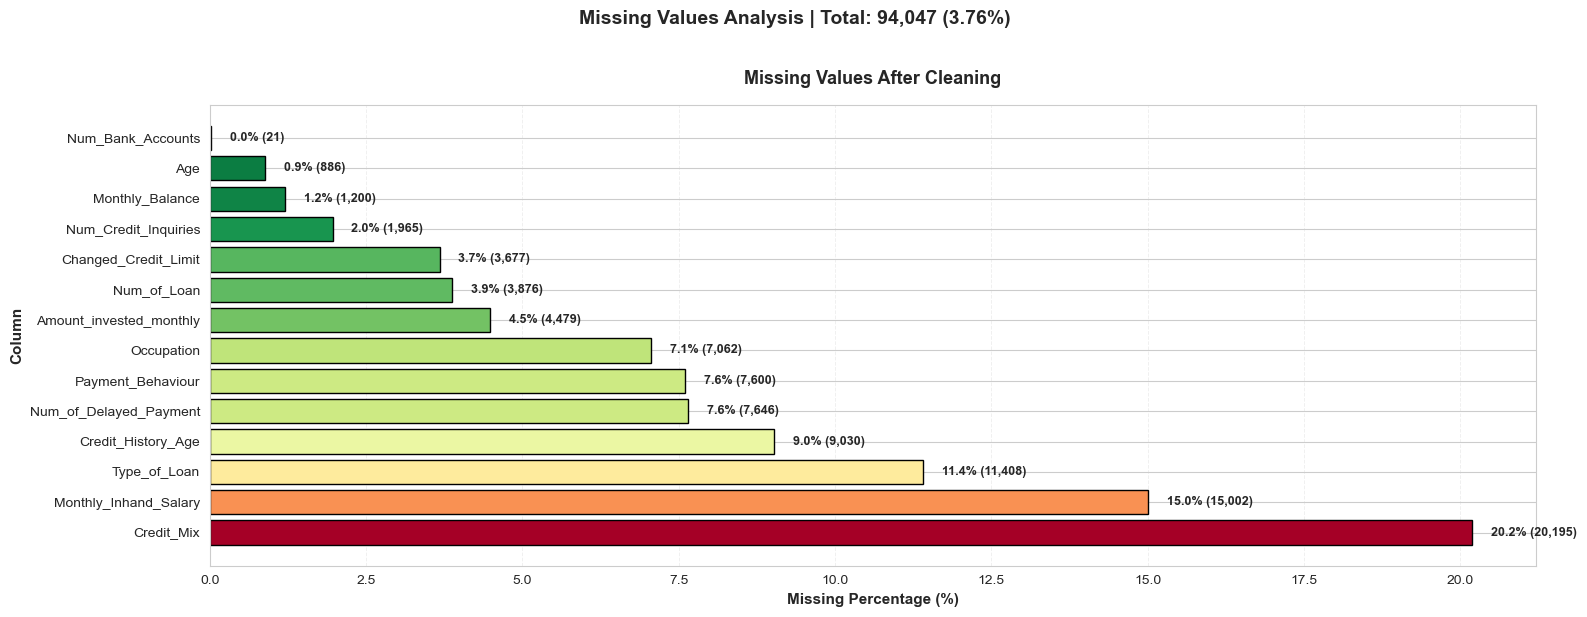


Columns with missing values: 14 out of 25


In [937]:
# Visualize missing values after cleaning
fig, ax1 = plt.subplots(1,1, figsize=(16, 6))

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, 
                edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values After Cleaning', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}% ({int(count):,})',
             ha='left', va='center', fontsize=9, fontweight='bold')

total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total: {int(total_missing):,} ({overall_pct:.2f}%)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print(f"\nColumns with missing values: {len(missing_df)} out of {df.shape[1]}")

In [938]:
# Check missing value counts
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:
Age                          886
Occupation                  7062
Monthly_Inhand_Salary      15002
Num_Bank_Accounts             21
Num_of_Loan                 3876
Type_of_Loan               11408
Num_of_Delayed_Payment      7646
Changed_Credit_Limit        3677
Num_Credit_Inquiries        1965
Credit_Mix                 20195
Credit_History_Age          9030
Amount_invested_monthly     4479
Payment_Behaviour           7600
Monthly_Balance             1200
dtype: int64


## 5.2 Imputation Strategy for Categorical Features

In [939]:
# Function to fill categorical missing values
# Strategy: Use mode per Customer_ID, otherwise use global mode
def fill_na_cat(data, val):
    nan_idx = list(data[val][data[val].isnull()].index)
    
    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].mode()[0]
        if not pd.isna(val_pred):
            data.loc[i, val] = val_pred
        else:
            data.loc[i, val] = data[val].mode()[0]
    
    return list(data[val])

print("Categorical imputation function defined")

Categorical imputation function defined


In [940]:
# Identify categorical columns with missing values (exclude Type_of_Loan for special handling)
missing_cat_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(include='object').columns.tolist())
missing_cat_cols.discard('Type_of_Loan')

print(f"Categorical columns to impute: {missing_cat_cols}")

Categorical columns to impute: {'Occupation', 'Credit_Mix', 'Payment_Behaviour'}


In [941]:
# Fill categorical missing values
for col in missing_cat_cols:
    df[col] = fill_na_cat(df, col)
    print(f'Filled {col} column')

print("\nCategorical imputation complete!")

Filled Occupation column
Filled Credit_Mix column
Filled Credit_Mix column
Filled Payment_Behaviour column

Categorical imputation complete!
Filled Payment_Behaviour column

Categorical imputation complete!


## 5.3 Imputation Strategy for Numerical Features

In [942]:
# Function to fill numerical missing values
# Strategy: Use median per Customer_ID, otherwise use global median
def fill_na_num(data, val):
    nan_idx = list(data[val][data[val].isnull()].index)
    
    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].median()
        
        if not pd.isna(val_pred):
            data.loc[i, val] = val_pred
        else:
            data.loc[i, val] = data[val].median()
    
    return data[val]

print("Numerical imputation function defined")

Numerical imputation function defined


In [943]:
# Identify numerical columns with missing values
missing_num_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(exclude='object').columns.tolist())

print(f"Numerical columns to impute: {missing_num_cols}")

Numerical columns to impute: {'Num_Bank_Accounts', 'Monthly_Balance', 'Monthly_Inhand_Salary', 'Changed_Credit_Limit', 'Credit_History_Age', 'Num_of_Delayed_Payment', 'Age', 'Num_Credit_Inquiries', 'Num_of_Loan', 'Amount_invested_monthly'}


In [944]:
# Fill numerical missing values
for col in missing_num_cols:
    df[col] = fill_na_num(df, col)
    print(f'Filled {col} column')

print("\nNumerical imputation complete!")

Filled Num_Bank_Accounts column
Filled Monthly_Balance column
Filled Monthly_Balance column
Filled Monthly_Inhand_Salary column
Filled Monthly_Inhand_Salary column
Filled Changed_Credit_Limit column
Filled Changed_Credit_Limit column
Filled Credit_History_Age column
Filled Credit_History_Age column
Filled Num_of_Delayed_Payment column
Filled Age column
Filled Num_of_Delayed_Payment column
Filled Age column
Filled Num_Credit_Inquiries column
Filled Num_Credit_Inquiries column
Filled Num_of_Loan column
Filled Num_of_Loan column
Filled Amount_invested_monthly column

Numerical imputation complete!
Filled Amount_invested_monthly column

Numerical imputation complete!


## 5.4 Special Handling for Type_of_Loan

In [945]:
# Analyze Type_of_Loan structure and extract all loan types
loan_types = {}

for idx, row in df.iterrows():
    vals = row['Type_of_Loan']
    if pd.isnull(vals): 
        continue
    
    vals = vals.replace('and', '').split(', ')
    for val in vals:
        val = val.strip()
        loan_types[val] = loan_types.get(val, 0) + 1

print("Loan types found:")
for k, v in loan_types.items():
    print(f'{k}: {v}')

Loan types found:
Auto Loan: 37992
Credit-Builder Loan: 40440
Personal Loan: 38888
Home Equity Loan: 39104
Not Specified: 39616
Mortgage Loan: 38936
Student Loan: 38968
Debt Consolidation Loan: 38776
Payday Loan: 40568


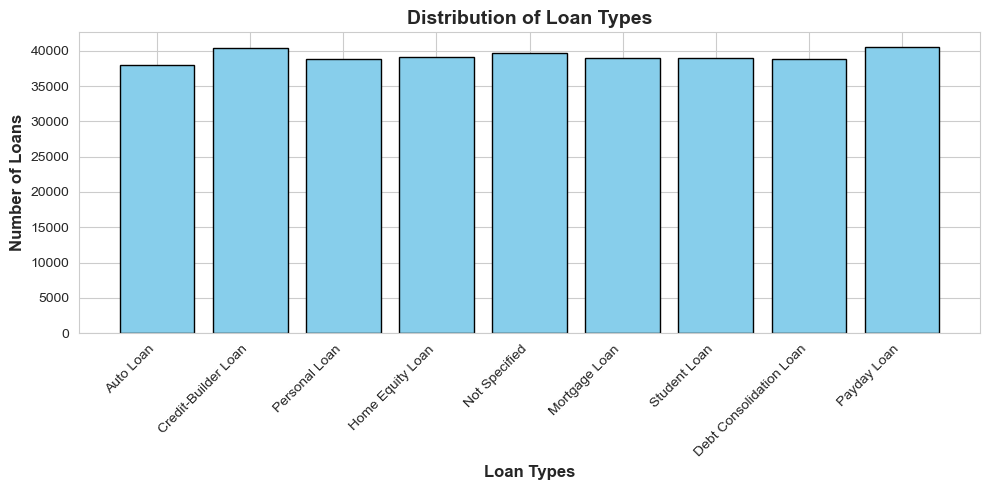

In [946]:
# Visualize loan types distribution
plt.figure(figsize=(10, 5))
plt.bar(loan_types.keys(), loan_types.values(), color='skyblue', edgecolor='black')
plt.xlabel('Loan Types', fontsize=12, fontweight='bold')
plt.ylabel('Number of Loans', fontsize=12, fontweight='bold')
plt.title('Distribution of Loan Types', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [947]:
# Check percentage of missing Type_of_Loan values
missing_pct = df['Type_of_Loan'].isna().sum() / len(df) * 100
print(f"Percentage of missing Type_of_Loan values: {missing_pct:.2f}%")

Percentage of missing Type_of_Loan values: 11.41%


## 5.5 Drop Remaining NaN Rows

In [948]:
# Drop rows with remaining NaN values (primarily Type_of_Loan)
shape_before = df.shape
df.dropna(inplace=True)
shape_after = df.shape

print(f"Shape before dropping NaN: {shape_before}")
print(f"Shape after dropping NaN: {shape_after}")
print(f"Rows dropped: {shape_before[0] - shape_after[0]}")

Shape before dropping NaN: (100000, 25)
Shape after dropping NaN: (88592, 25)
Rows dropped: 11408


## 5.6 Verification

In [949]:
# Verify no missing values remain
print("Remaining missing values:")
print(df.isna().sum().sum())
print("\nMissing value treatment complete! ✓")

Remaining missing values:
0

Missing value treatment complete! ✓
0

Missing value treatment complete! ✓


# === 6. FEATURE ENGINEERING ===

## 6.1 Type_of_Loan Expansion to Binary Columns

In [950]:
# Create binary columns for each loan type
col_map = {True: 1, False: 0}

for loan_type in list(loan_types.keys()):
    df[loan_type] = df['Type_of_Loan'].str.contains(loan_type).map(col_map)

print(f"Created {len(loan_types)} binary loan type columns")
df.info()

Created 9 binary loan type columns
<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               88592 non-null  int64  
 1   Month                     88592 non-null  object 
 2   Age                       88592 non-null  float64
 3   Occupation                88592 non-null  object 
 4   Annual_Income             88592 non-null  float64
 5   Monthly_Inhand_Salary     88592 non-null  float64
 6   Num_Bank_Accounts         88592 non-null  float64
 7   Num_Credit_Card           88592 non-null  int64  
 8   Interest_Rate             88592 non-null  int64  
 9   Num_of_Loan               88592 non-null  float64
 10  Type_of_Loan              88592 non-null  object 
 11  Delay_from_due_date       88592 non-null  int64  
 12  Num_of_Delayed_Payment    88592 non-null  float64
 13  Changed_Credit_Limit      88592

## 6.2 Drop Original Type_of_Loan and 'Not Specified'

In [951]:
# Drop the original Type_of_Loan column and 'Not Specified' column
df.drop(['Type_of_Loan', 'Not Specified'], axis=1, inplace=True)

print(f"Dropped Type_of_Loan and 'Not Specified' columns")
print(f"Current shape: {df.shape}")

Dropped Type_of_Loan and 'Not Specified' columns
Current shape: (88592, 32)


## 6.3 Reorder Columns (Move Target to End)

In [952]:
# Move Credit_Score to the end for consistency
y = df['Credit_Score']
df = df.drop('Credit_Score', axis=1)
df['Credit_Score'] = y

print("Moved Credit_Score to last column")
print(f"Final shape after feature engineering: {df.shape}")

Moved Credit_Score to last column
Final shape after feature engineering: (88592, 32)


# === 7. ADVANCED EDA & FEATURE ANALYSIS ===

## 7.1 Select Numerical Columns for Analysis

In [953]:
# Select numerical columns (excluding Customer_ID and loan type binary columns)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-8].tolist()

print(f"Number of numerical columns for analysis: {len(num_cols)}")
print(f"\nNumerical columns: {num_cols}")

Number of numerical columns for analysis: 17

Numerical columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


## 7.2 KDE Plots by Credit Score

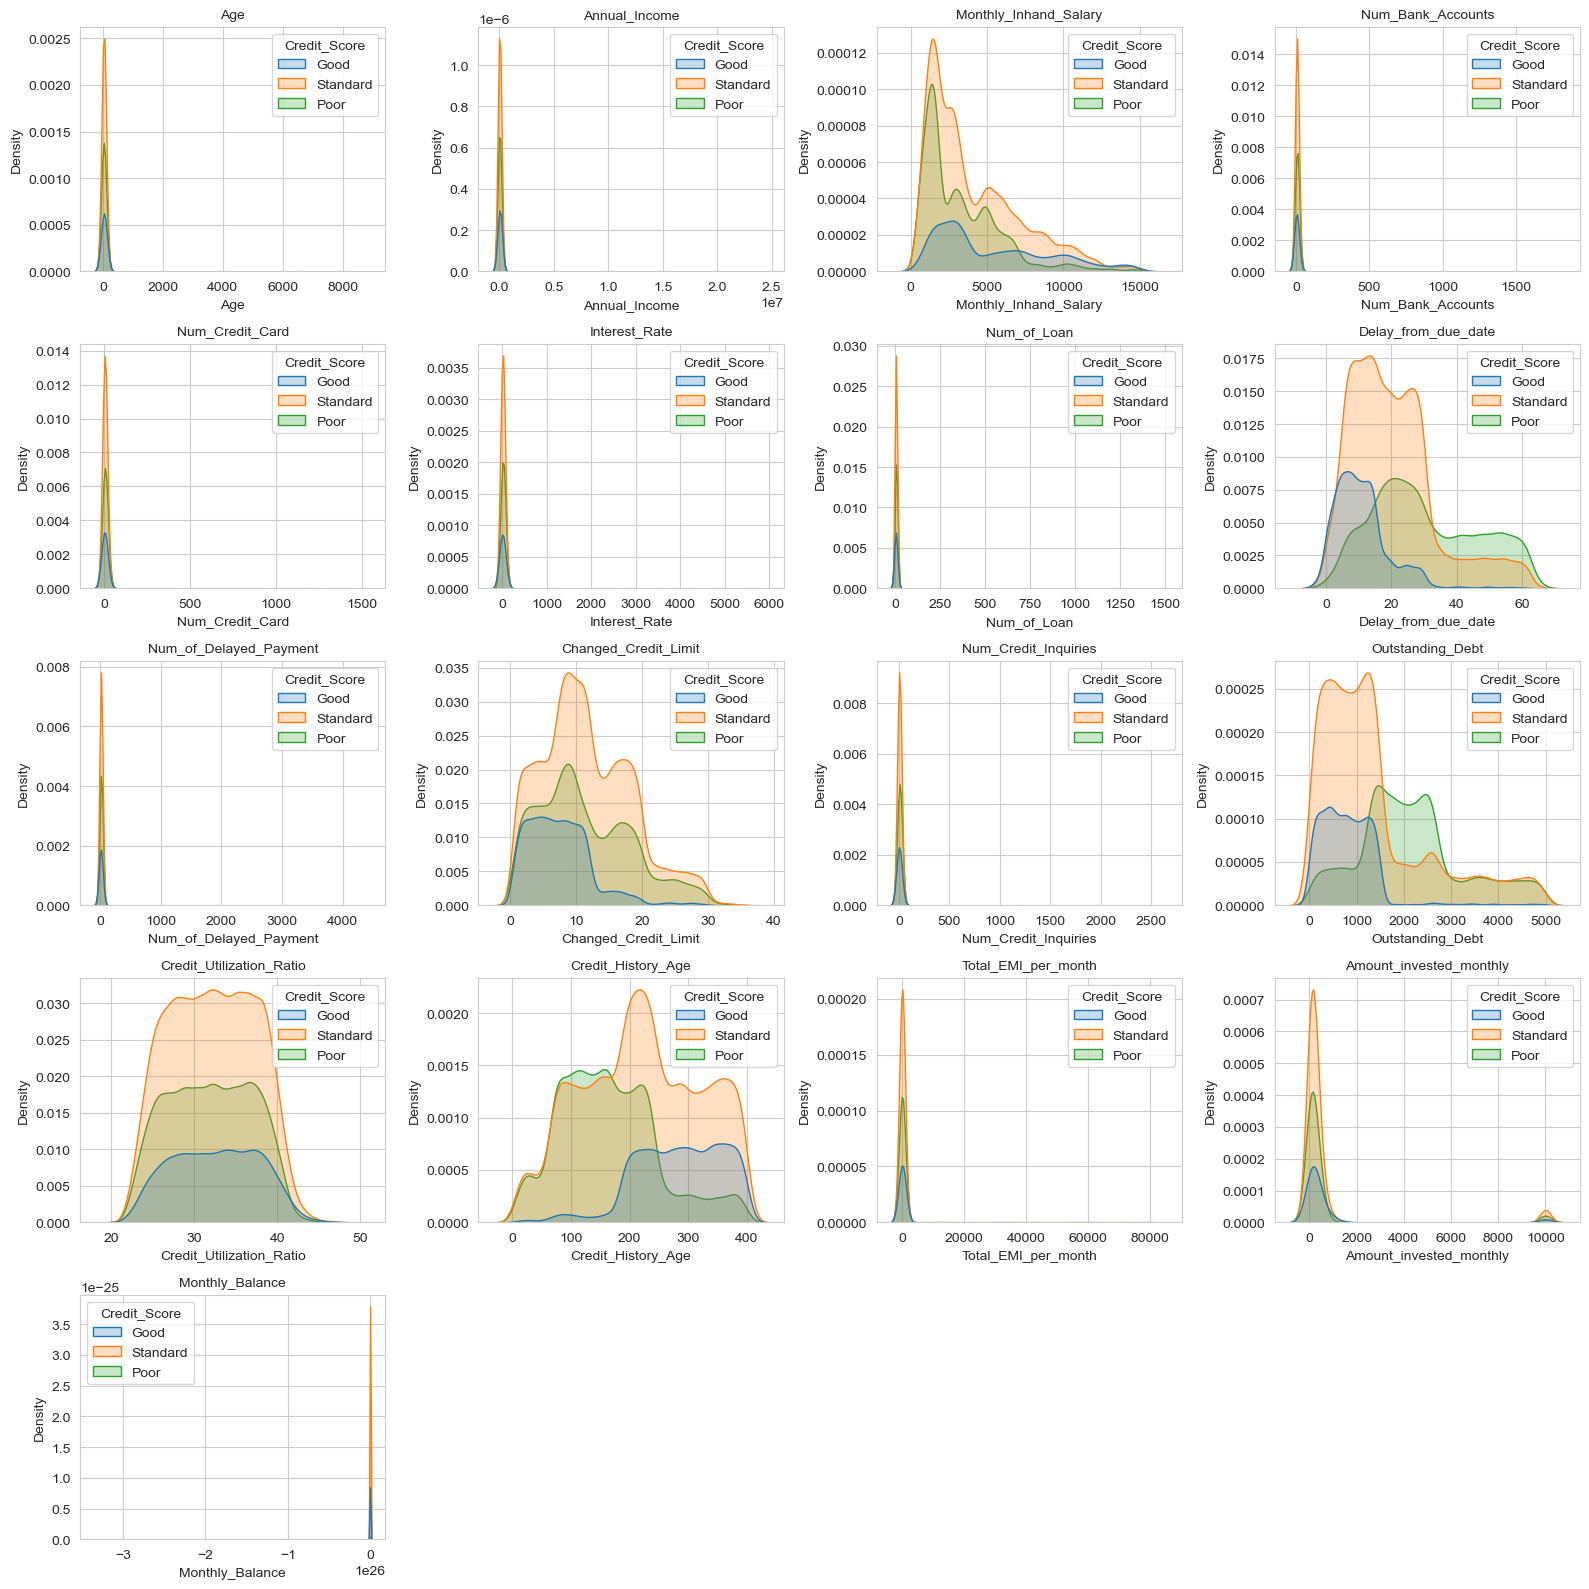

In [954]:
# KDE plots for numerical features colored by Credit Score
plt.figure(figsize=(16, 16))

for ax, col in enumerate(num_cols):
    plt.subplot(5, 4, ax + 1)
    plt.title(col, fontsize=10)
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'])

plt.tight_layout()
plt.show()

## 7.3 Pairplot for Key Features

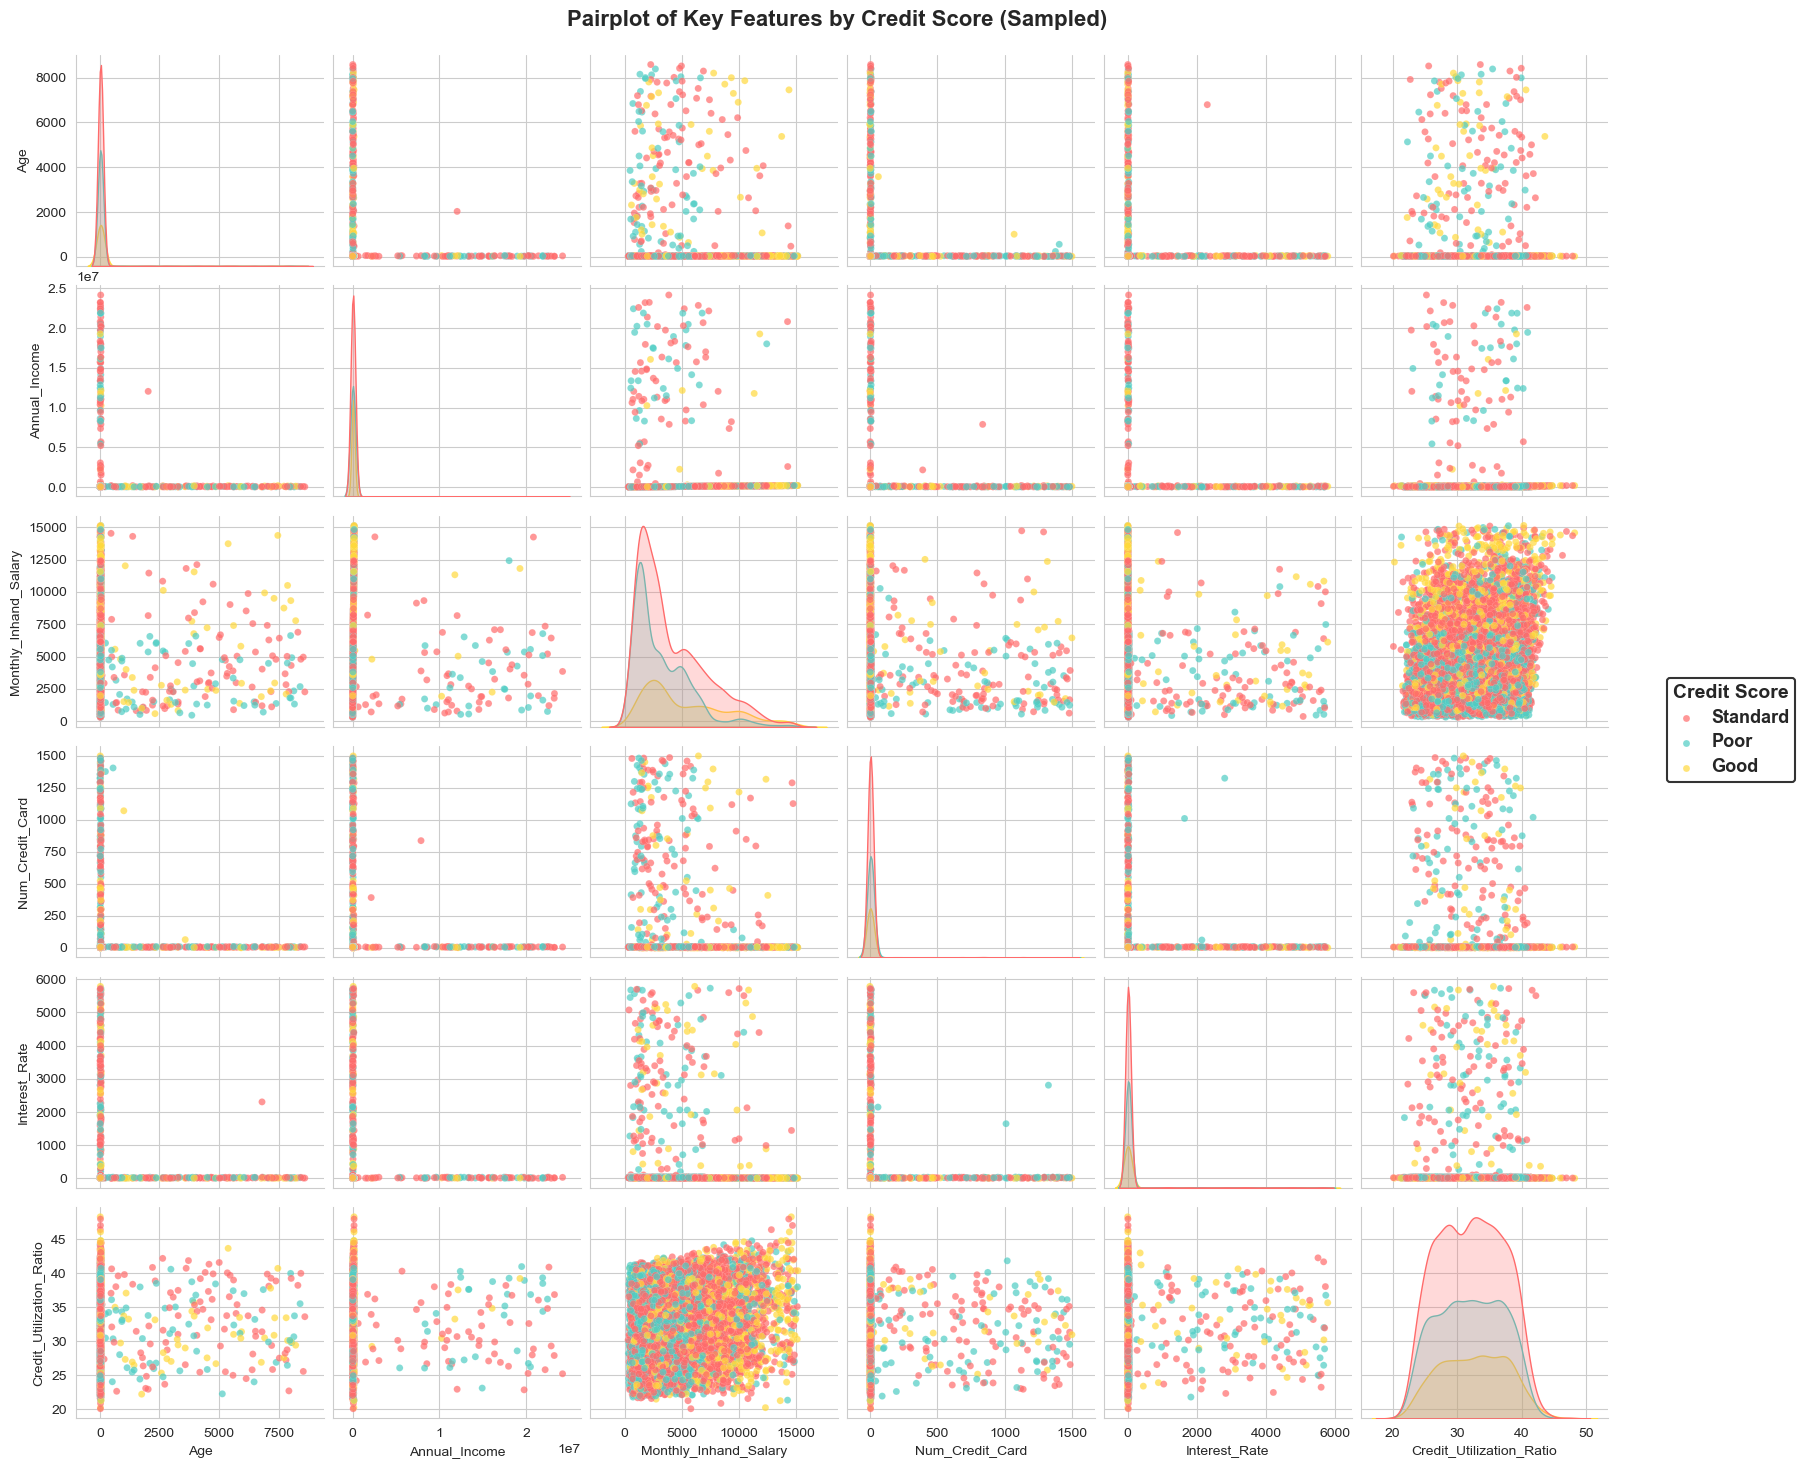


Pairplot generated successfully!
Features analyzed: 6
Target classes: ['Standard' 'Poor' 'Good']
Sample size used: 10000


In [955]:
# Create pairplot for selected key features to visualize relationships
# Note: Using original Credit_Score values (Poor, Standard, Good) before encoding
key_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Credit_Card',
                'Interest_Rate', 'Credit_Utilization_Ratio', 'Credit_Score']

pairplot_df = df[key_features].dropna().copy()

# Sampling limits the number of rows to keep the plot performant on large datasets
sample_size = min(10000, len(pairplot_df))
pairplot_sample = pairplot_df.sample(n=sample_size, random_state=42)

# Use more vibrant colors for better visibility
vibrant_colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']  # Bright Red, Cyan, Yellow

g = sns.pairplot(pairplot_sample, hue='Credit_Score', palette=vibrant_colors,
                 plot_kws={'alpha': 0.7, 's': 25, 'edgecolor': 'white', 'linewidth': 0.1}, 
                 diag_kind='kde', height=2.5, aspect=1)

# Move legend outside and customize for better visibility
g._legend.remove()  # Remove default legend
g.add_legend(title='Credit Score', bbox_to_anchor=(0.98, 0.5), loc='center left')
g._legend.set_frame_on(True)
g._legend.get_frame().set_facecolor('white')
g._legend.get_frame().set_edgecolor('black')
g._legend.get_frame().set_linewidth(1.5)

# Make legend text larger and bold
for text in g._legend.texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

# Make legend title bold and larger
g._legend.get_title().set_fontsize(14)
g._legend.get_title().set_fontweight('bold')

g.figure.subplots_adjust(top=0.95, right=0.95)
g.figure.suptitle('Pairplot of Key Features by Credit Score (Sampled)', y=0.98,
               fontsize=16, fontweight='bold')
plt.show()

print("\nPairplot generated successfully!")
print(f"Features analyzed: {len(key_features) - 1}")
print(f"Target classes: {pairplot_sample['Credit_Score'].unique()}")
print(f"Sample size used: {sample_size}")

## 7.5 Chi-Square Tests for Categorical Independence

In [956]:
# Chi-square test function
def chi_square_test(data, col1, col2='Credit_Score'):
    occ = data[[col1, col2]]
    table = pd.crosstab(index=occ[col1], columns=occ[col2])
    t, p, sd, expected = stats.chi2_contingency(table)
    return t, p

print("Chi-square test function defined")

Chi-square test function defined


In [957]:
# Prepare test dataframe
q_test_cols = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
test_df = df[q_test_cols].copy()
test_df['Credit_Score'] = df['Credit_Score']

print("Test dataframe prepared")
test_df.head()

Test dataframe prepared


,Month,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,January,Scientist,Good,No,High_spent_Small_value_payments,Good
1,February,Scientist,Good,No,Low_spent_Large_value_payments,Good
2,March,Scientist,Good,No,Low_spent_Medium_value_payments,Good
3,April,Scientist,Good,No,Low_spent_Small_value_payments,Good
4,May,Scientist,Good,No,High_spent_Medium_value_payments,Good


In [958]:
# Perform chi-square tests for all categorical variables
cols, values, p_values = [], [], []

for col in test_df.columns[:-1].tolist():
    cols.append(col)
    t, p = chi_square_test(test_df, col)
    values.append(round(t, 2))
    p_values.append(round(p, 2))

chi_df = pd.DataFrame({
    'Variable': cols,
    'Chi2_Value': values,
    'P_value': p_values
})

chi_df = chi_df.sort_values(by='Chi2_Value', ascending=False)
chi_df.style.bar('Chi2_Value').background_gradient('Blues', subset='Chi2_Value')

,Variable,Chi2_Value,P_value
2,Credit_Mix,36275.530000,0.000000
3,Payment_of_Min_Amount,15380.350000,0.000000
4,Payment_Behaviour,1442.730000,0.000000
1,Occupation,175.220000,0.000000
0,Month,171.880000,0.000000


## 7.6 ANOVA Tests for Numerical Features

In [959]:
# Drop features with low chi-square values before ANOVA (Month and Occupation)
df.drop(['Month', 'Occupation'], axis=1, inplace=True)

print("Dropped Month and Occupation based on chi-square test results")
print(f"New shape: {df.shape}")

Dropped Month and Occupation based on chi-square test results
New shape: (88592, 30)


In [960]:
# Select numeric features for ANOVA testing
df_numeric = df.select_dtypes(include=['int', 'float'])

# Remove loan type binary columns for this analysis
cols_to_drop_temp = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
]

df_numeric_test = df_numeric.drop(cols_to_drop_temp, axis=1)

# Add Credit_Score column which is required for the boxplots and ANOVA grouping
df_numeric_test['Credit_Score'] = df['Credit_Score']

print(f"Numerical columns for ANOVA: {len(df_numeric_test.columns)}")
print(df_numeric_test.columns.tolist())

Numerical columns for ANOVA: 19
['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score']


In [961]:
# ANOVA test function using Welch's ANOVA
def anova_test(data, col1, col2='Credit_Score'):
    df_test = data[[col1, col2]]
    df_melted = pd.melt(df_test, id_vars=col2, var_name=col1, value_name='value')
    test = pg.welch_anova(data=df_melted, dv='value', between=col2)
    return test

print("ANOVA test function defined")

ANOVA test function defined


In [962]:
# Perform ANOVA tests for all numerical variables
cols, values, p_values = [], [], []

for col in df_numeric_test.columns[:-1]:
    cols.append(col)
    test = anova_test(df, col)
    values.append(round(float(test['F'].values), 2))
    p_values.append(round(float(test['p-unc'].values), 2))

anova_df = pd.DataFrame({
    'Variable': cols,
    'F_Value': values,
    'P_value': p_values
})

anova_df = anova_df.sort_values(by='F_Value', ascending=False)
anova_df.style.bar('F_Value').background_gradient('Blues', subset='F_Value')

,Variable,F_Value,P_value
8,Delay_from_due_date,13121.570000,0.000000
12,Outstanding_Debt,11763.220000,0.000000
14,Credit_History_Age,11195.130000,0.000000
10,Changed_Credit_Limit,3632.120000,0.000000
3,Monthly_Inhand_Salary,2101.910000,0.000000
13,Credit_Utilization_Ratio,73.750000,0.000000
0,Customer_ID,8.910000,0.000000
11,Num_Credit_Inquiries,7.580000,0.000000
16,Amount_invested_monthly,6.280000,0.000000
4,Num_Bank_Accounts,5.520000,0.000000


In [963]:
# Drop features with lowest ANOVA F-values (bottom 3)
cols_to_drop = anova_df['Variable'][-3:].tolist()
df.drop(cols_to_drop, axis=1, inplace=True)

print(f"Dropped features with low ANOVA scores: {cols_to_drop}")
print(f"New shape: {df.shape}")

Dropped features with low ANOVA scores: ['Monthly_Balance', 'Age', 'Total_EMI_per_month']
New shape: (88592, 27)


In [964]:
# Display final columns after feature selection
print("Final columns after statistical feature selection:")
print(df.columns.tolist())

Final columns after statistical feature selection:
['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan', 'Mortgage Loan', 'Student Loan', 'Debt Consolidation Loan', 'Payday Loan', 'Credit_Score']


# === 8. OUTLIER DETECTION & TREATMENT ===

## 8.1 Define Outlier Detection Functions

In [965]:
# Define outlier detection functions using IQR method
def outlier_thresholds(data, col_name):
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    return lower_limit, upper_limit

def check_outlier(data, col_name):
    lower_limit, upper_limit = outlier_thresholds(data, col_name)
    
    outliers = data[(data[col_name] > upper_limit) | (data[col_name] < lower_limit)]
    percentage_outliers = (len(outliers) / len(data)) * 100
    
    return outliers.any(axis=None), round(percentage_outliers, 2)

print("Outlier detection functions defined")

Outlier detection functions defined


## 8.2 Outlier Percentage Analysis

In [966]:
# Update num_cols after feature selection
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-8].tolist()

# Identify outliers in all numerical columns
outlier_rows = []

for col in num_cols:
    has_outliers, percentage = check_outlier(df, col)
    outlier_rows.append({
        'Column': col,
        'Has_Outliers': has_outliers,
        'Percentage': percentage
    })

outlier_results = pd.DataFrame(outlier_rows)
outlier_results = outlier_results[outlier_results['Has_Outliers']]
outlier_results = outlier_results[outlier_results['Percentage'] > 1]
outlier_results = outlier_results.sort_values(by='Percentage')

print("Outlier Analysis Results:")
outlier_results

Outlier Analysis Results:


,Column,Has_Outliers,Percentage
2,Num_Bank_Accounts,True,1.31
9,Num_Credit_Inquiries,True,1.64
4,Interest_Rate,True,2.05
3,Num_Credit_Card,True,2.24
1,Monthly_Inhand_Salary,True,2.31
0,Annual_Income,True,2.94
6,Delay_from_due_date,True,3.27
10,Outstanding_Debt,True,3.44
13,Amount_invested_monthly,True,10.49


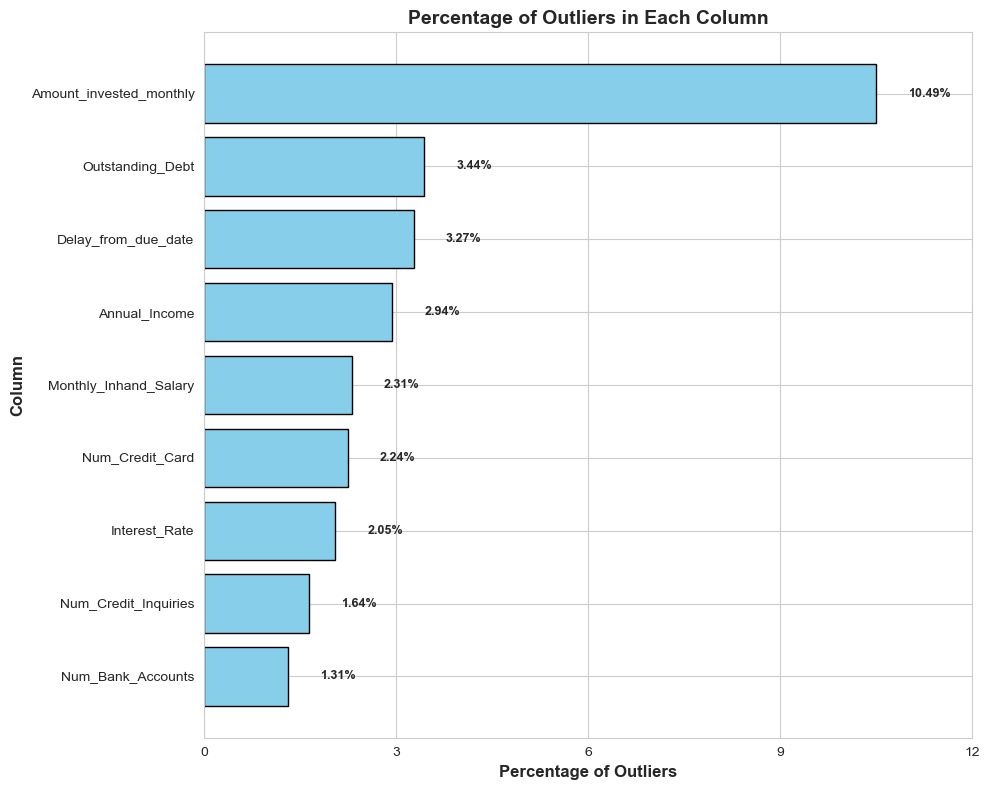

In [967]:
# Visualize outlier percentages
plt.figure(figsize=(10, 8))
bars = plt.barh(outlier_results['Column'], outlier_results['Percentage'], 
                color='skyblue', edgecolor='black')
plt.xlabel('Percentage of Outliers', fontsize=12, fontweight='bold')
plt.ylabel('Column', fontsize=12, fontweight='bold')
plt.title('Percentage of Outliers in Each Column', fontsize=14, fontweight='bold')
plt.xticks(np.arange(0, outlier_results['Percentage'].max() + 3, 3))

for bar, label in zip(bars, outlier_results['Percentage']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, 
             f'{label:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 8.3 Boxplot Visualization (Before Treatment)

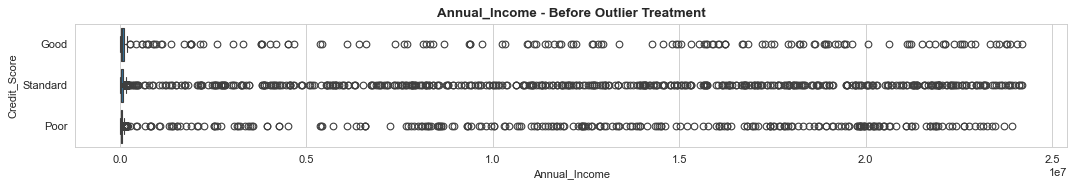

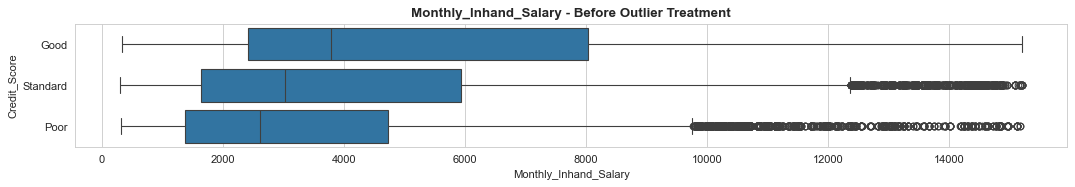

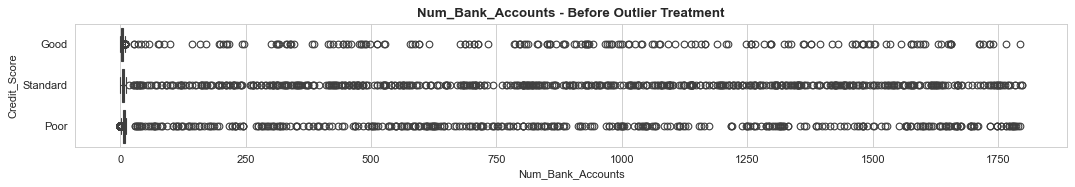

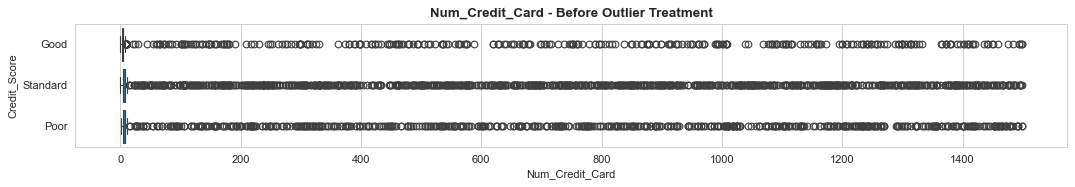

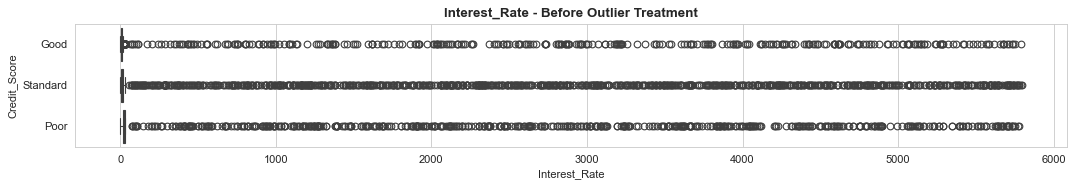

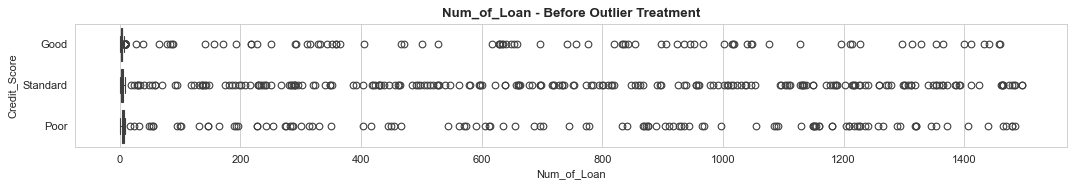

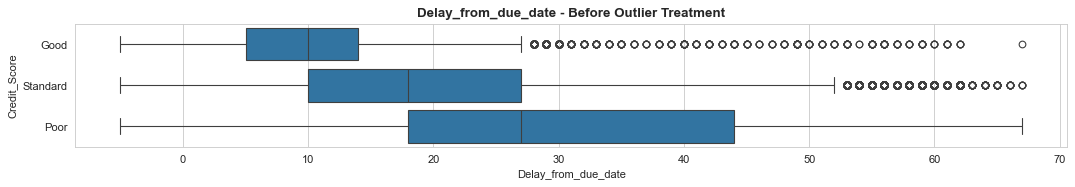

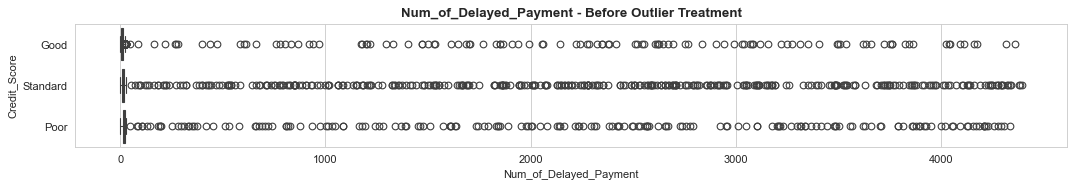

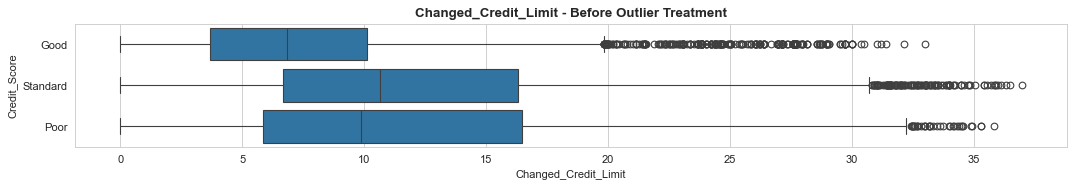

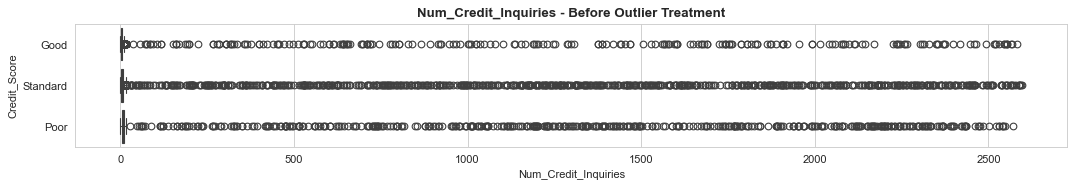

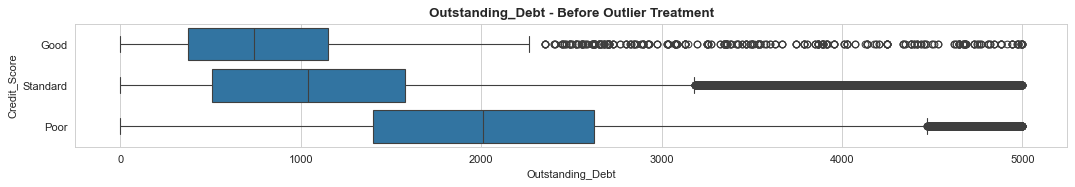

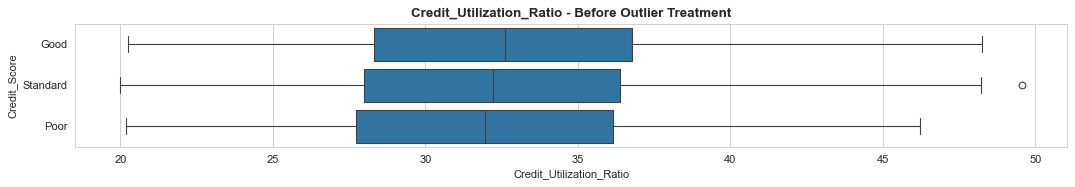

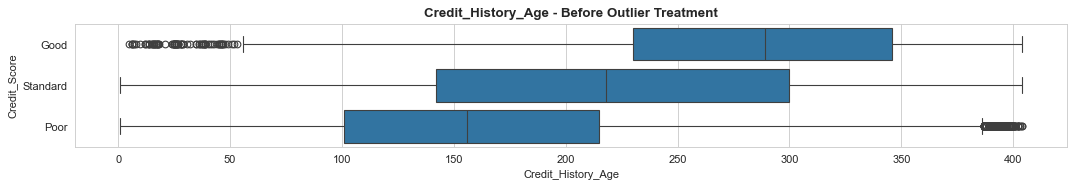

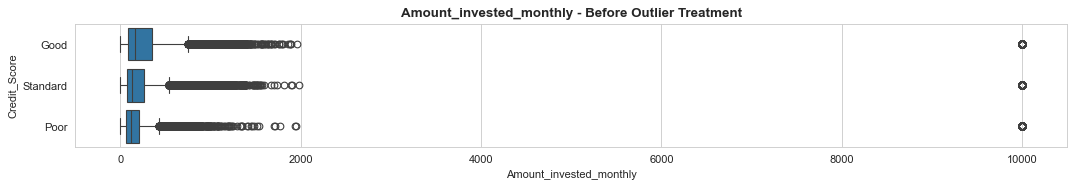

In [968]:
# Boxplots for each numerical feature by Credit Score (BEFORE outlier treatment)
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    sns.boxplot(x=df[col], y=df['Credit_Score'], data=df, orient='h')
    plt.title(f'{col} - Before Outlier Treatment', fontweight='bold')
    plt.show()

## 8.4 Outlier Treatment (Capping)

In [969]:
# Function to replace outliers with threshold values (capping)
def replace_with_thresholds(data, col):
    lower_limit, upper_limit = outlier_thresholds(data, col)
    
    data.loc[(data[col] < lower_limit), col] = lower_limit
    data.loc[(data[col] > upper_limit), col] = upper_limit

# Apply outlier capping to all numerical columns
for col in num_cols:
    replace_with_thresholds(df, col)

print("Outlier treatment complete - all outliers capped at IQR boundaries")

Outlier treatment complete - all outliers capped at IQR boundaries


## 8.5 Boxplot Visualization (After Treatment)

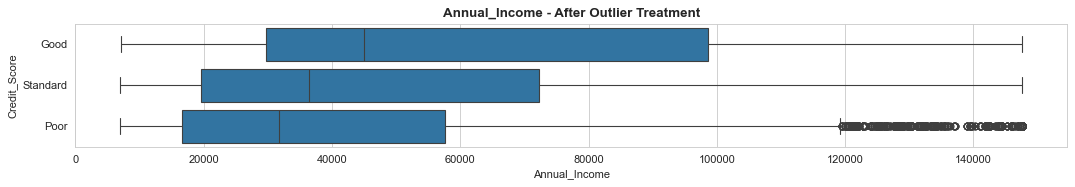

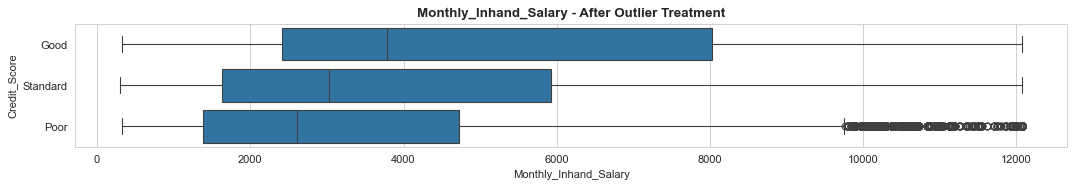

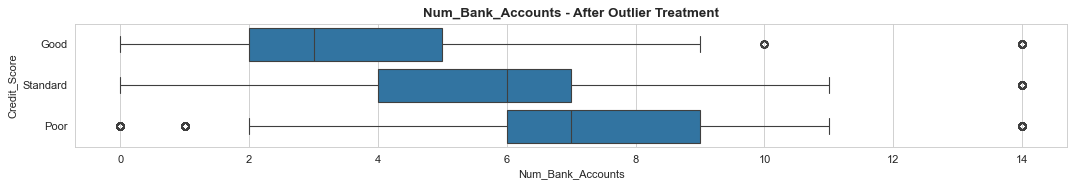

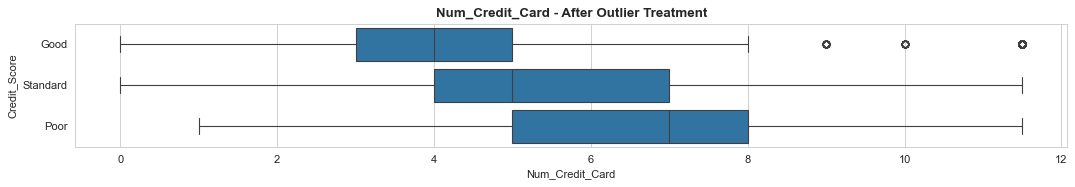

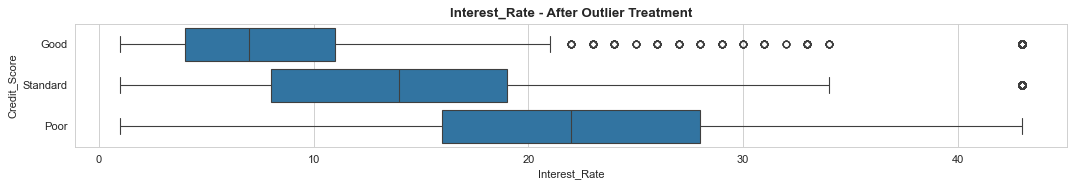

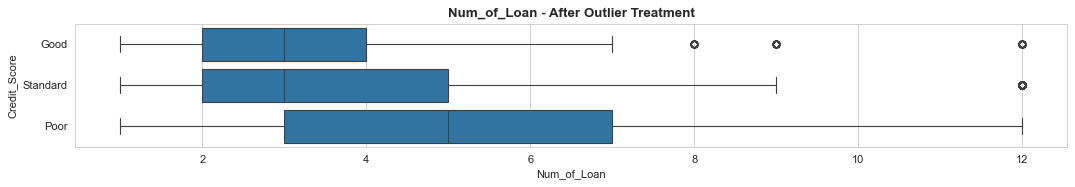

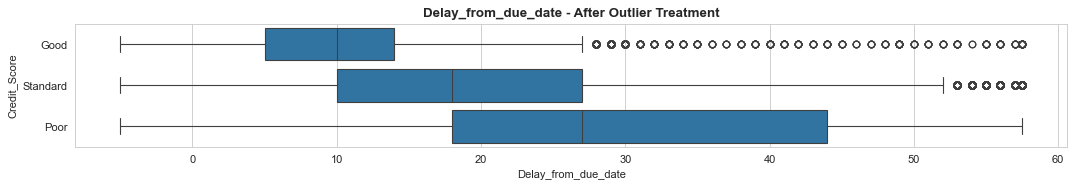

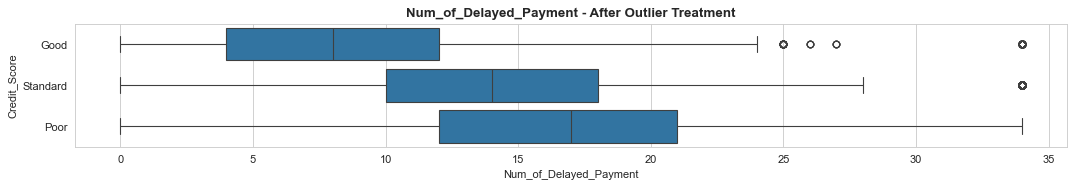

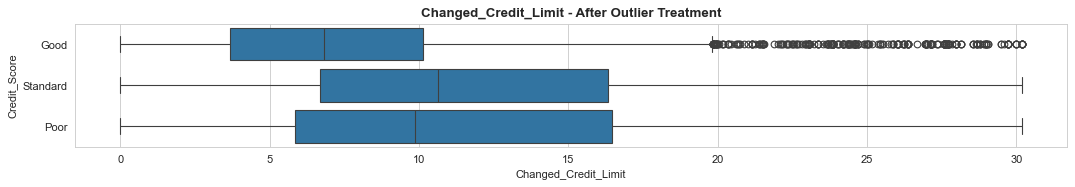

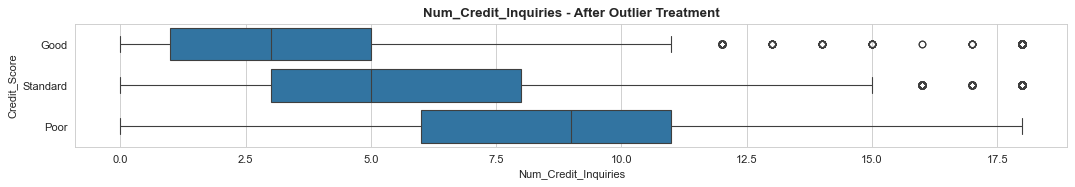

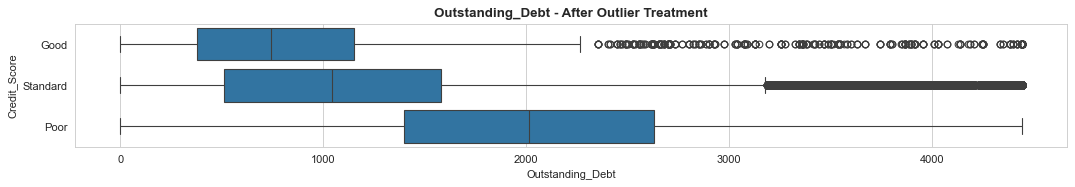

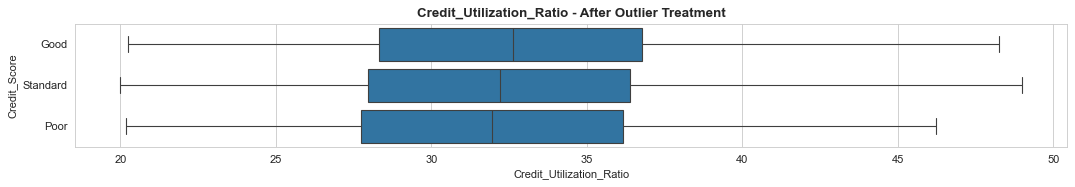

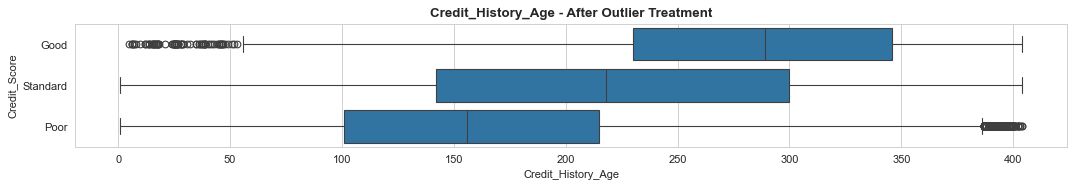

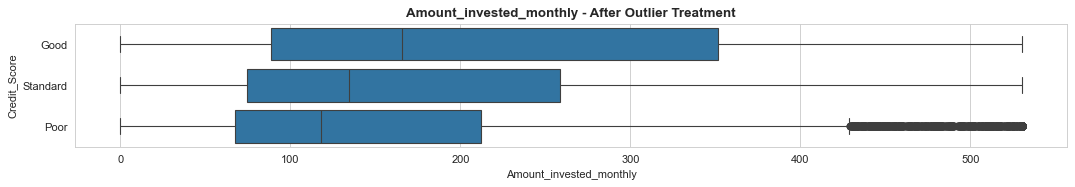

In [970]:
# Boxplots for each numerical feature by Credit Score (AFTER outlier treatment)
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    sns.boxplot(x=df[col], y=df['Credit_Score'], data=df, orient='h')
    plt.title(f'{col} - After Outlier Treatment', fontweight='bold')
    plt.show()

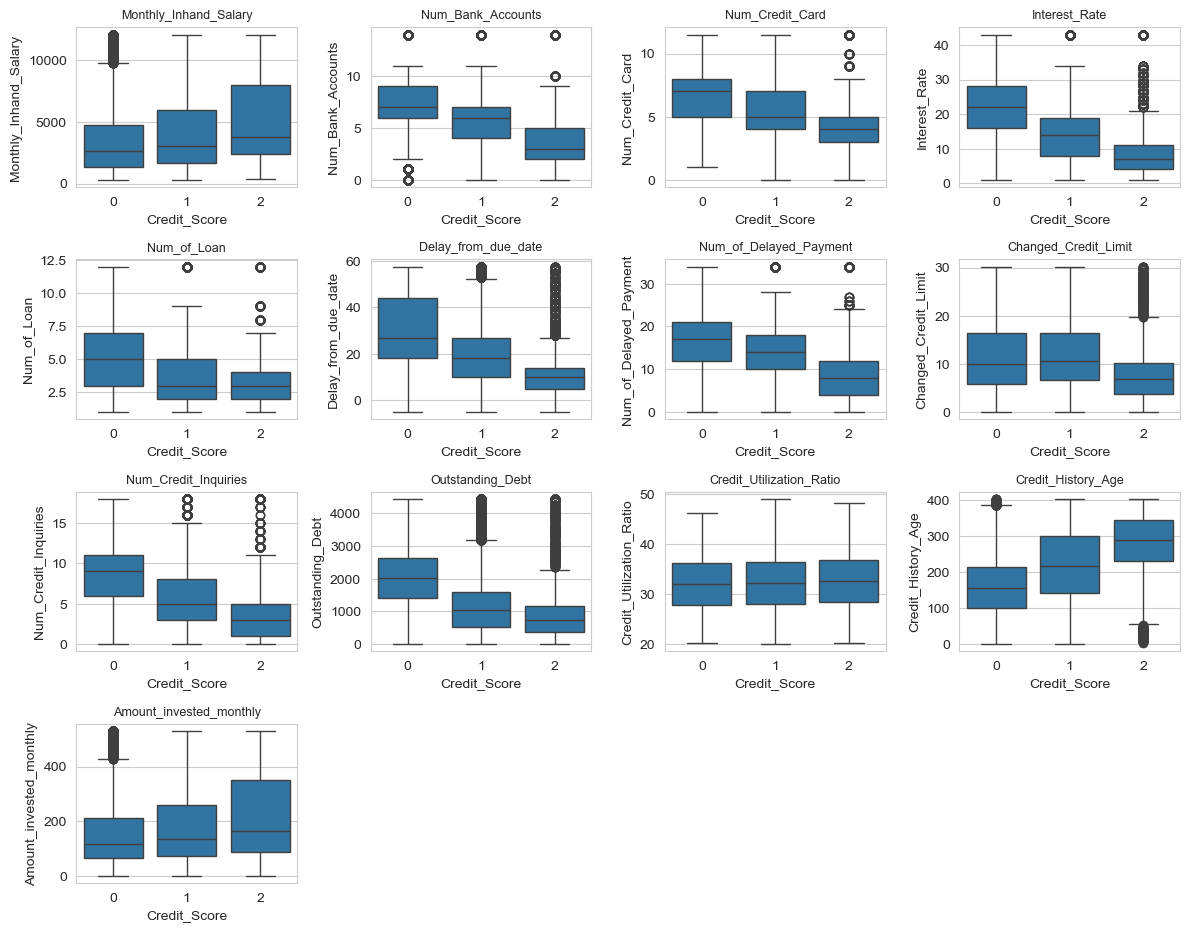

Multi-panel boxplot visualization complete - data shown AFTER outlier treatment


In [971]:
# Multi-panel boxplot visualization with encoded Credit_Score
# This shows the data state AFTER outlier treatment with proper ordering

# Create a temporary dataframe with encoded Credit_Score for visualization
df_temp = df.copy()
temp_label_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_temp['Credit_Score'] = df_temp['Credit_Score'].map(temp_label_map)

# Select numeric columns (excluding Customer_ID and loan type binary columns)
df_numeric_vis = df_temp.select_dtypes(include=['int', 'float'])

# Remove loan type binary columns
cols_to_drop_vis = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
]
df_numeric_vis = df_numeric_vis.drop(cols_to_drop_vis, axis=1)

plt.figure(figsize=(12, 16))

for ax, col in enumerate(df_numeric_vis.columns[2:-1]):
    plt.subplot(7, 4, ax + 1)
    plt.title(col, fontsize=9)
    # Use order parameter to ensure Poor (0), Standard (1), Good (2) ordering
    sns.boxplot(x='Credit_Score', y=col, data=df_numeric_vis, order=[0, 1, 2])

plt.tight_layout()
plt.show()

print("Multi-panel boxplot visualization complete - data shown AFTER outlier treatment")

## 8.6 Distribution Comparison (Before/After)

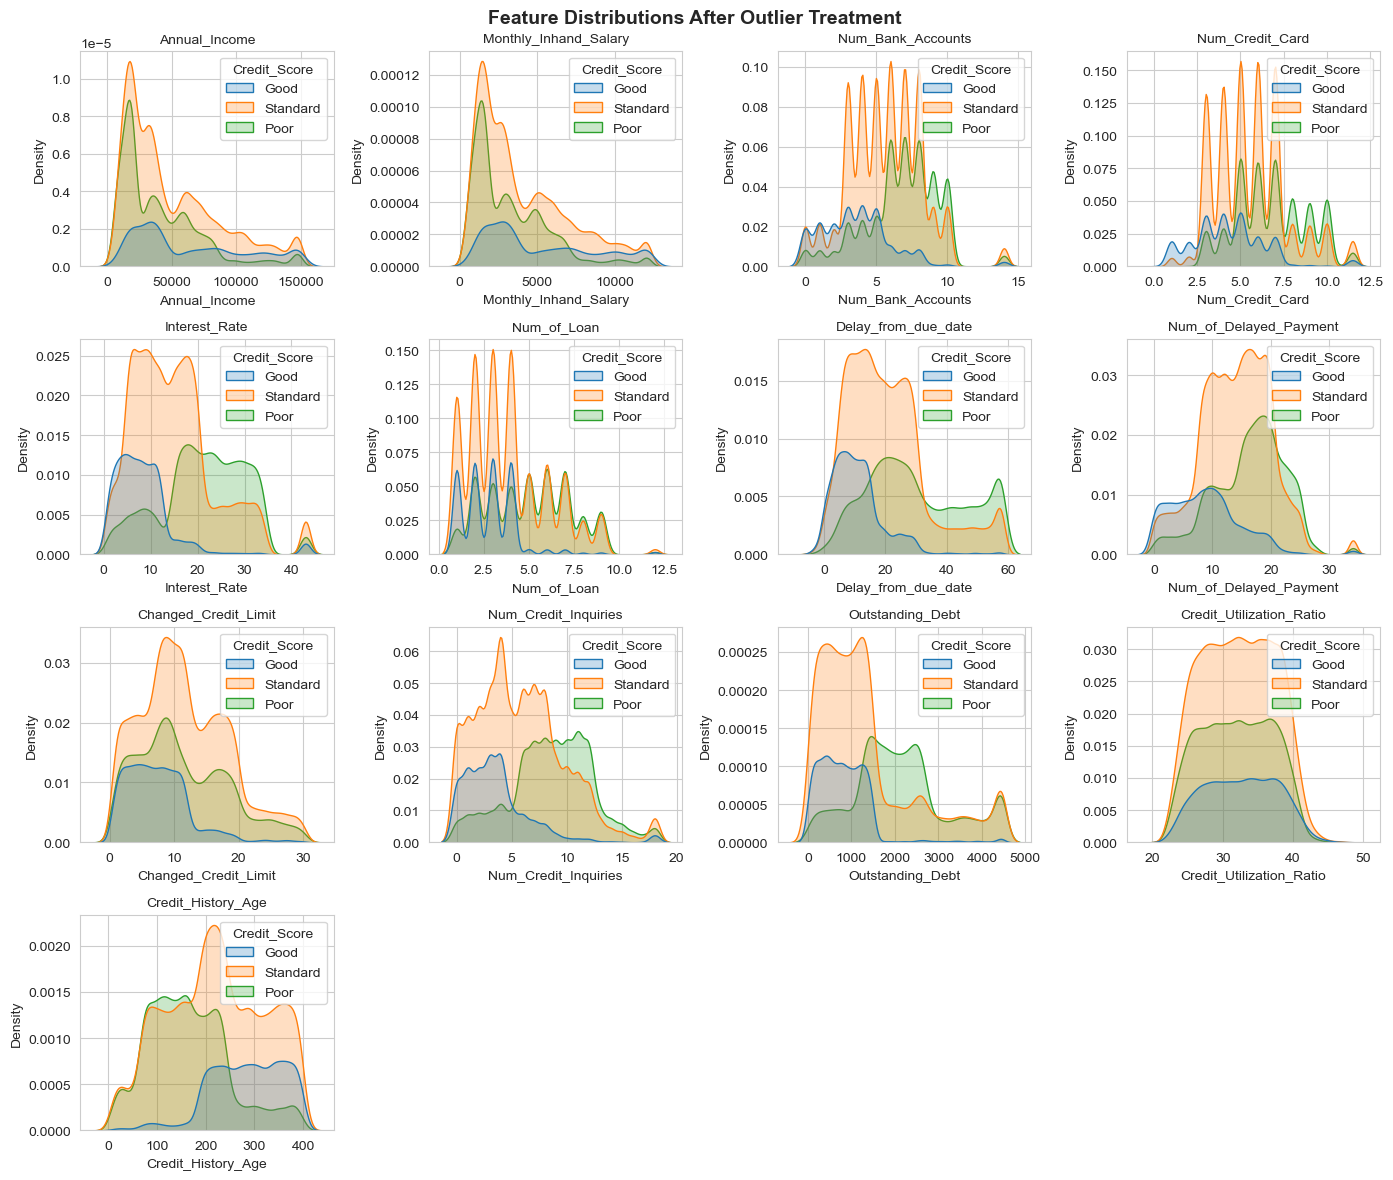

In [972]:
# KDE plots showing distribution after outlier treatment
plt.figure(figsize=(14, 12))

for ax, col in enumerate(num_cols[:-1]):
    plt.subplot(4, 4, ax + 1)
    plt.title(col, fontsize=10)
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'])

plt.suptitle('Feature Distributions After Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === 9. FEATURE ENCODING ===

## 9.1 Target Variable Encoding

In [973]:
# Encode Credit_Score: Poor=0, Standard=1, Good=2
label_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

df['Credit_Score'] = df['Credit_Score'].map(label_map)

print("Credit Score encoding:")
print(df['Credit_Score'].value_counts().sort_index())

Credit Score encoding:
Credit_Score
0    27662
1    46546
2    14384
Name: count, dtype: int64


## 9.2 Separate Features and Target

## 9.1b Visualize Categorical Features vs Encoded Target

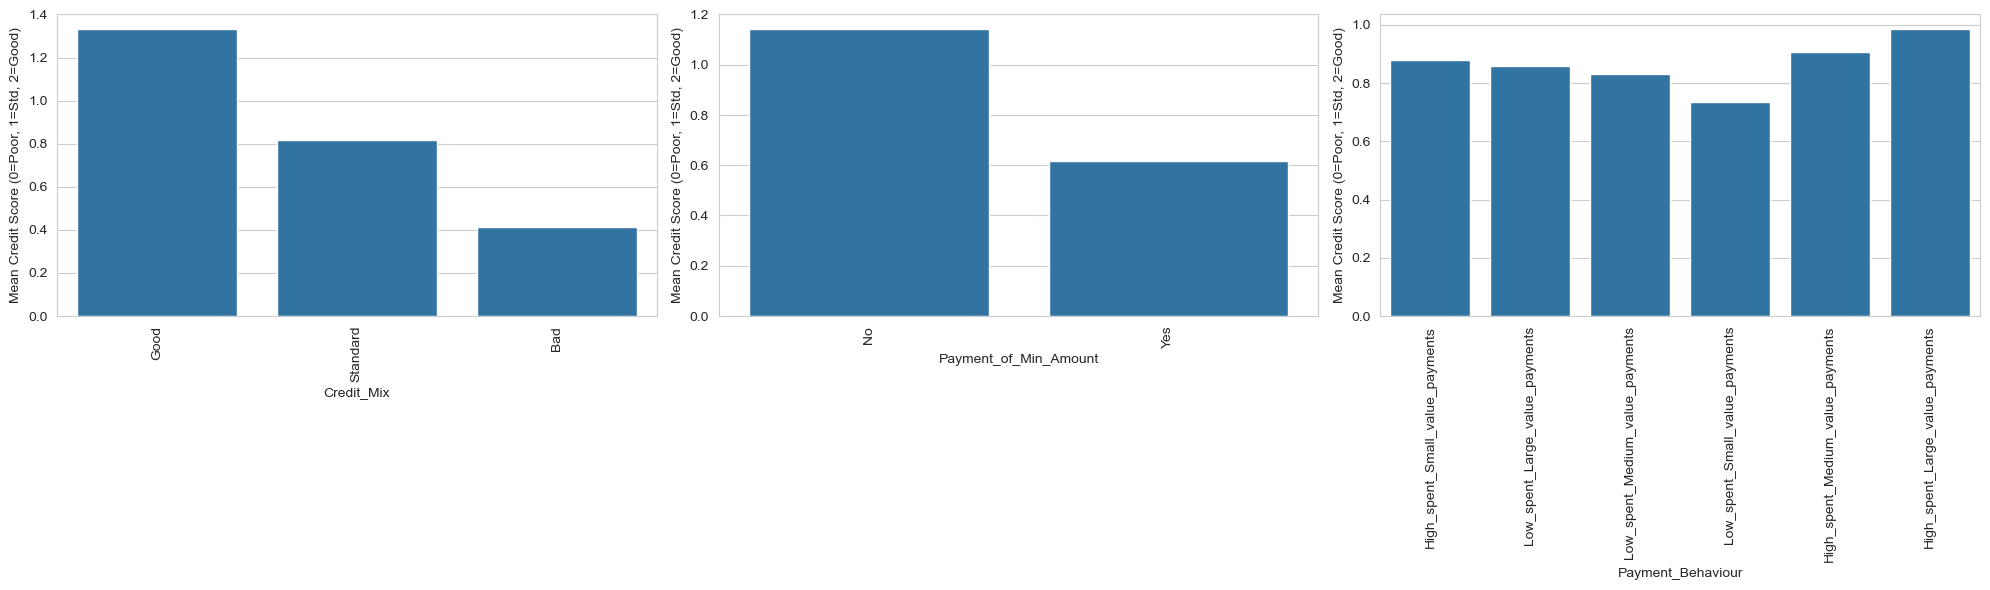

In [974]:
# Visualize relationship between categorical features and Credit Score (now numeric)
# Y-axis shows the mean Credit Score value (0=Poor, 1=Standard, 2=Good)
cat_cols = df.select_dtypes(include='object').columns.tolist()

if len(cat_cols) > 0:
    plt.figure(figsize=(20, 6))
    
    for i, col in enumerate(cat_cols, start=1):
        plt.subplot(1, len(cat_cols), i)
        g = sns.barplot(x=col, y='Credit_Score', data=df, errorbar=None)
        g.set_ylabel('Mean Credit Score (0=Poor, 1=Std, 2=Good)')
        g.set_xlabel(col)
        g.set_xticklabels(g.get_xticklabels(), rotation=90)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns remaining at this stage.")

In [975]:
# Separate features (X) and target (y)
features = df.drop('Credit_Score', axis=1)
label = df['Credit_Score']

print(f"Features shape: {features.shape}")
print(f"Label shape: {label.shape}")
print(f"\nLabel distribution:")
print(label.value_counts().sort_index())

Features shape: (88592, 26)
Label shape: (88592,)

Label distribution:
Credit_Score
0    27662
1    46546
2    14384
Name: count, dtype: int64


## 9.3 Encode Categorical Features

In [976]:
# Check remaining categorical columns
cat_col = features.select_dtypes(include='object').columns.tolist()

print(f"Remaining categorical columns: {cat_col}")
for col in cat_col:
    print(f"\n{col} value counts:")
    print(features[col].value_counts())

Remaining categorical columns: ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

Credit_Mix value counts:
Credit_Mix
Standard    40736
Good        24088
Bad         23768
Name: count, dtype: int64

Payment_of_Min_Amount value counts:
Payment_of_Min_Amount
Yes    49515
No     39077
Name: count, dtype: int64

Payment_Behaviour value counts:
Payment_Behaviour
Low_spent_Small_value_payments      25227
High_spent_Medium_value_payments    16993
High_spent_Large_value_payments     13199
Low_spent_Medium_value_payments     12887
High_spent_Small_value_payments     10613
Low_spent_Large_value_payments       9673
Name: count, dtype: int64


In [977]:
# Ordinal encoding for Credit_Mix (Bad=0, Standard=1, Good=2)
cred_mix = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}

features['Credit_Mix'] = features['Credit_Mix'].map(cred_mix)

# Binary encoding for Payment_of_Min_Amount (No=0, Yes=1)
min_pay = {
    'No': 0,
    'Yes': 1,
}

features['Payment_of_Min_Amount'] = features['Payment_of_Min_Amount'].map(min_pay)

print("Ordinal encoding complete for Credit_Mix and Payment_of_Min_Amount")

Ordinal encoding complete for Credit_Mix and Payment_of_Min_Amount


In [978]:
# One-hot encoding for Payment_Behaviour (drop_first to avoid multicollinearity)
features = pd.get_dummies(features, columns=['Payment_Behaviour'], drop_first=True, dtype=int)

print(f"One-hot encoding complete")
print(f"New features shape: {features.shape}")

One-hot encoding complete
New features shape: (88592, 30)


## 9.4 Data Type Optimization

In [979]:
# Convert float columns that contain only integers to int type
float_cols_with_integers = df.select_dtypes(include='float').apply(
    lambda col: col.apply(lambda x: x.is_integer())).all()
float_cols_to_convert = float_cols_with_integers[float_cols_with_integers].index

features[float_cols_to_convert] = features[float_cols_to_convert].astype(int)

print(f"Converted {len(float_cols_to_convert)} float columns to int")

Converted 2 float columns to int


In [980]:
#  Credit_History_Age to int
features['Credit_History_Age'] = features['Credit_History_Age'].astype(int)


## 9.5 Final Feature Overview

In [981]:
# Display features info
print("Features Information:")
features.info()

print("\nFeatures sample:")
features.head()

Features Information:
<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Customer_ID                                         88592 non-null  int64  
 1   Annual_Income                                       88592 non-null  float64
 2   Monthly_Inhand_Salary                               88592 non-null  float64
 3   Num_Bank_Accounts                                   88592 non-null  int64  
 4   Num_Credit_Card                                     88592 non-null  float64
 5   Interest_Rate                                       88592 non-null  int64  
 6   Num_of_Loan                                         88592 non-null  int64  
 7   Delay_from_due_date                                 88592 non-null  float64
 8   Num_of_Delayed_Payment                              88592 n

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Home Equity Loan,Mortgage Loan,Student Loan,Debt Consolidation Loan,Payday Loan,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,3392,19114.12,1824.843333,3,4.0,3,4,3.0,7.0,11.27,...,1,0,0,0,0,0,1,0,0,0
1,3392,19114.12,1824.843333,3,4.0,3,4,-1.0,6.5,11.27,...,1,0,0,0,0,0,0,1,0,0
2,3392,19114.12,1824.843333,3,4.0,3,4,3.0,7.0,11.27,...,1,0,0,0,0,0,0,0,1,0
3,3392,19114.12,1824.843333,3,4.0,3,4,5.0,4.0,6.27,...,1,0,0,0,0,0,0,0,0,1
4,3392,19114.12,1824.843333,3,4.0,3,4,6.0,6.5,11.27,...,1,0,0,0,0,1,0,0,0,0


## 9.6 Post-Encoding Correlation Matrix

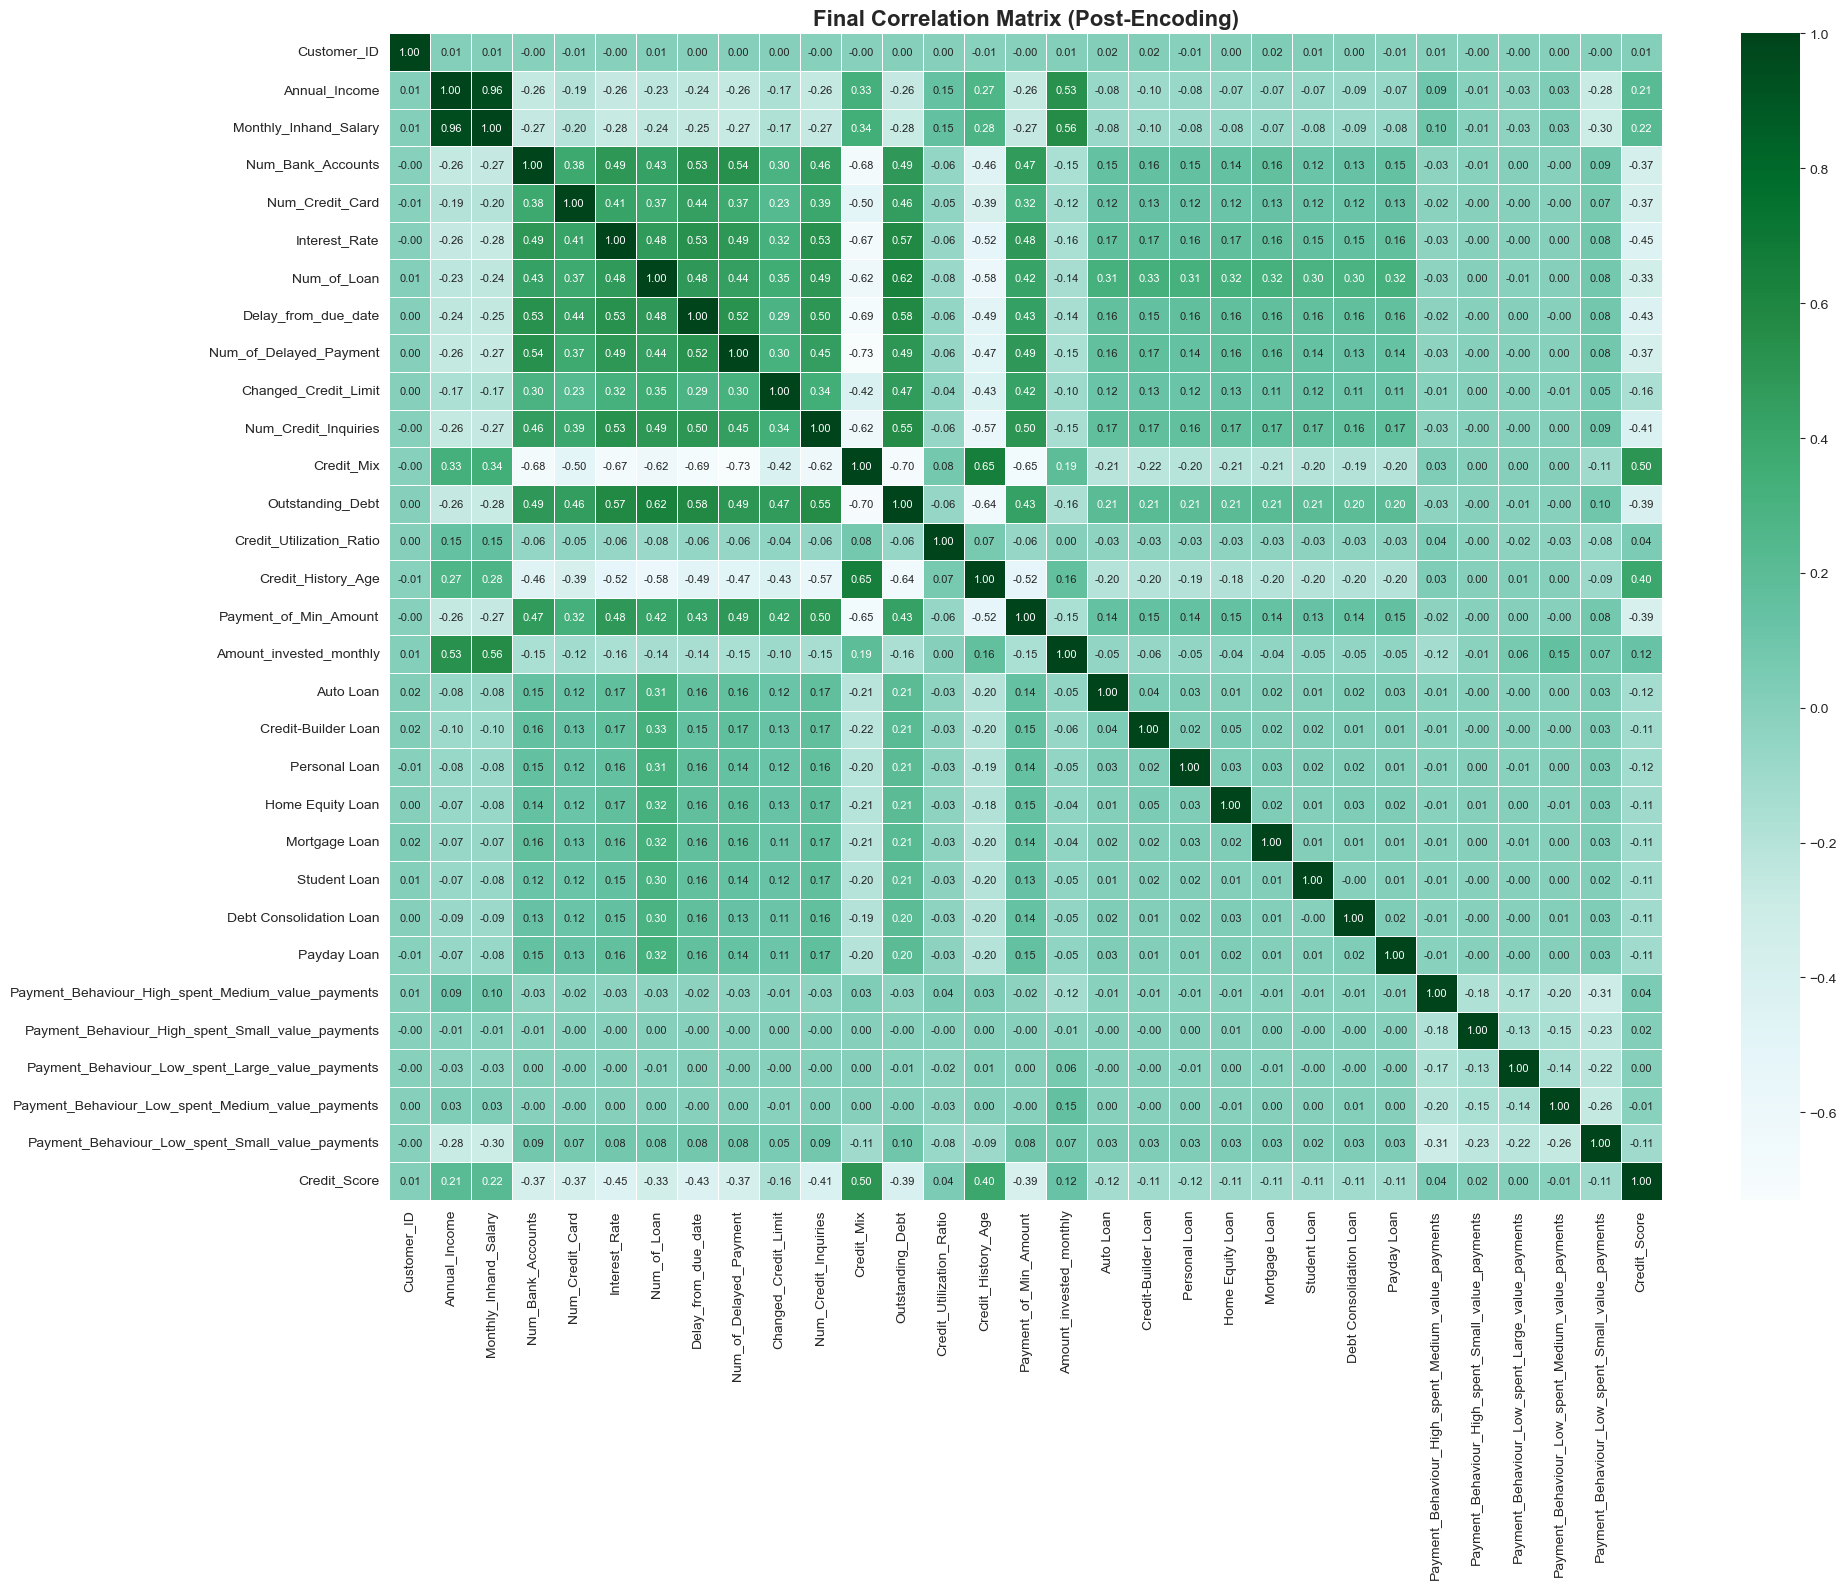

In [982]:
# Create final correlation matrix with all encoded features
final_df = features.copy()
final_df['Credit_Score'] = label

corr_matrix = final_df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5, annot_kws={'size': 8})
plt.title('Final Correlation Matrix (Post-Encoding)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# === 10. PREPROCESSING FOR MODELING ===

## 10.1 Feature-Target Split Verification

In [983]:
# Verify features and target are properly separated
print("="*60)
print("FEATURE-TARGET SPLIT VERIFICATION")
print("="*60)

print(f"\nFeatures (X) shape: {features.shape}")
print(f"Target (y) shape: {label.shape}")

print(f"\nNumber of features: {features.shape[1]}")
print(f"Number of samples: {features.shape[0]}")

print(f"\nFeatures data types:")
print(features.dtypes.value_counts())

print(f"\nTarget distribution:")
print(label.value_counts().sort_index())
print(f"\nTarget distribution (%):")
print(label.value_counts(normalize=True).sort_index() * 100)

FEATURE-TARGET SPLIT VERIFICATION

Features (X) shape: (88592, 30)
Target (y) shape: (88592,)

Number of features: 30
Number of samples: 88592

Features data types:
int64      20
float64    10
Name: count, dtype: int64

Target distribution:
Credit_Score
0    27662
1    46546
2    14384
Name: count, dtype: int64

Target distribution (%):
Credit_Score
0    31.224038
1    52.539733
2    16.236229
Name: proportion, dtype: float64


## 10.2 Train-Test Split (Stratified)

In [984]:
# Split data into training and testing sets (80-20 split with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    label, 
    test_size=0.2, 
    random_state=42, 
    stratify=label
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(features)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(features)*100:.1f}%)")

print(f"\nTraining set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting set class distribution:")
print(y_test.value_counts().sort_index())

TRAIN-TEST SPLIT

Training set size: 70873 samples (80.0%)
Testing set size: 17719 samples (20.0%)

Training set shape: X_train=(70873, 30), y_train=(70873,)
Testing set shape: X_test=(17719, 30), y_test=(17719,)

Training set class distribution:
Credit_Score
0    22129
1    37237
2    11507
Name: count, dtype: int64

Testing set class distribution:
Credit_Score
0    5533
1    9309
2    2877
Name: count, dtype: int64


## 10.3 Feature Selection and Scaling

In [985]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Feature Selection to reduce noise and overfitting
print("🔍 Applying Feature Selection...")

# Store original feature count before selection
original_feature_count = X_train.shape[1]

selector = SelectKBest(mutual_info_classif, k=20)

# Fit on training data and transform both sets
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()

# Convert back to DataFrames with proper column names
X_train = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

print(f"✅ Reduced from {original_feature_count} to {X_train.shape[1]} features")
print(f"📊 Selected features: {selected_features}")

🔍 Applying Feature Selection...
✅ Reduced from 30 to 20 features
📊 Selected features: ['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Credit-Builder Loan', 'Home Equity Loan', 'Student Loan', 'Payday Loan']
✅ Reduced from 30 to 20 features
📊 Selected features: ['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Credit-Builder Loan', 'Home Equity Loan', 'Student Loan', 'Payday Loan']


In [986]:
# Dual Scaling: RobustScaler for most models, MinMaxScaler for MultinomialNB

# RobustScaler (outlier-robust)
robust_scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled = robust_scaler.fit_transform(X_train_scaled)
X_test_scaled = robust_scaler.transform(X_test_scaled)

# MinMaxScaler (non-negative features for MultinomialNB)
minmax_scaler = MinMaxScaler()
X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()

X_train_minmax = minmax_scaler.fit_transform(X_train_minmax)
X_test_minmax = minmax_scaler.transform(X_test_minmax)

print(f"✅ Scaled data: {X_train_scaled.shape}")
print(f"✅ MinMax scaled data: {X_train_minmax.shape}")

✅ Scaled data: (70873, 20)
✅ MinMax scaled data: (70873, 20)


# === 11. MODELING & EVALUATION ===

## 11.1 Import Additional Libraries

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import time

sns.set_style('whitegrid')

Additional modeling libraries imported successfully!


## 11.2 Helper Function: Train and Evaluate

In [ ]:
def train_and_evaluate(model, param_grid, name, use_minmax=False):
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")
    
    # Select appropriate scaled data based on model requirements
    if use_minmax:
        X_train_data = X_train_minmax
        y_train_data = y_train
        X_test_data = X_test_minmax
        print("Using MinMaxScaler data (non-negative features)")
    else:
        X_train_data = X_train_scaled
        y_train_data = y_train
        X_test_data = X_test_scaled
        print("Using RobustScaler data")
    
    start_time = time.time()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_data, y_train_data)
    training_time = time.time() - start_time
    
    best_model = grid_search.best_estimator_
    
    # Predictions for training and test sets
    y_train_pred = best_model.predict(X_train_data)
    y_pred = best_model.predict(X_test_data)
    y_pred_proba = best_model.predict_proba(X_test_data)
    
    # Training metrics
    train_accuracy = accuracy_score(y_train_data, y_train_pred)
    train_precision = precision_score(y_train_data, y_train_pred, average='weighted', zero_division=0)
    train_recall = recall_score(y_train_data, y_train_pred, average='weighted', zero_division=0)
    train_f1 = f1_score(y_train_data, y_train_pred, average='weighted', zero_division=0)
    
    # Test metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    accuracy_gap = train_accuracy - accuracy
    precision_gap = train_precision - precision
    recall_gap = train_recall - recall
    f1_gap = train_f1 - f1
    max_gap = max(accuracy_gap, precision_gap, recall_gap, f1_gap)
    
    if max_gap > 0.15:
        overfitting_status = "🔴 Severe overfitting"
    elif max_gap > 0.1:
        overfitting_status = "🟡 Moderate overfitting"
    elif max_gap > 0.05:
        overfitting_status = "🟢 Mild overfitting"
    else:
        overfitting_status = "✅ No significant overfitting"
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Training Time: {training_time:.2f}s")
    print(f"Training Accuracy: {train_accuracy:.4f} | Test Accuracy: {accuracy:.4f} | Gap: {accuracy_gap:.4f}")
    print(f"Training F1:       {train_f1:.4f} | Test F1:       {f1:.4f} | Gap: {f1_gap:.4f}")
    print(f"Overfitting Status: {overfitting_status}")
    
    print("CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=['Poor', 'Standard', 'Good']))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{name} - Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=['Poor', 'Standard', 'Good'], 
                yticklabels=['Poor', 'Standard', 'Good'])
    axes[0].set_title('Confusion Matrix', fontweight='bold')
    axes[0].set_xlabel('Predicted', fontweight='bold')
    axes[0].set_ylabel('Actual', fontweight='bold')
    
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']
    class_names = ['Poor', 'Standard', 'Good']
    
    for i, color, class_name in zip(range(3), colors, class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')
    
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1].set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)
    axes[1].grid(alpha=0.3)
    
    train_sizes, train_scores, val_scores = learning_curve(
        best_model, X_train_data, y_train_data, 
        cv=5, scoring='f1_weighted', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    axes[2].plot(train_sizes, train_mean, 'o-', color='#2E86AB', lw=2, label='Training Score')
    axes[2].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                         alpha=0.2, color='#2E86AB')
    axes[2].plot(train_sizes, val_mean, 'o-', color='#A23B72', lw=2, label='Validation Score')
    axes[2].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                         alpha=0.2, color='#A23B72')
    axes[2].set_xlabel('Training Size', fontweight='bold')
    axes[2].set_ylabel('F1 Score', fontweight='bold')
    axes[2].set_title('Learning Curve (Overfitting Check)', fontweight='bold')
    axes[2].legend(loc='lower right', fontsize=10)
    axes[2].grid(alpha=0.3)
    axes[2].text(0.03, 0.05, f"Final Gap: {train_mean[-1] - val_mean[-1]:.3f}",
                 transform=axes[2].transAxes,
                 fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return {
        'Model': name,
        'Best_Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Training_Time': training_time,
        'Train_Accuracy': train_accuracy,
        'Train_Precision': train_precision,
        'Train_Recall': train_recall,
        'Train_F1': train_f1,
        'Accuracy_Gap': accuracy_gap,
        'Precision_Gap': precision_gap,
        'Recall_Gap': recall_gap,
        'F1_Gap': f1_gap,
        'Overfitting_Status': overfitting_status,
        'Best_Estimator': best_model
    }


## 11.3 Model 1: Gaussian Naive Bayes


Training: Gaussian Naive Bayes
Using RobustScaler data
Fitting 11 folds for each of 4 candidates, totalling 44 fits

Best Parameters: {'var_smoothing': 1e-09}
Training Time: 0.81s
Training Accuracy: 0.6160 | Test Accuracy: 0.6166 | Gap: -0.0007
Training F1:       0.6176 | Test F1:       0.6190 | Gap: -0.0014
Overfitting Status: ✅ No significant overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.63      0.71      0.67      5533
    Standard       0.79      0.49      0.61      9309
        Good       0.42      0.83      0.56      2877

    accuracy                           0.62     17719
   macro avg       0.61      0.68      0.61     17719
weighted avg       0.68      0.62      0.62     17719


Best Parameters: {'var_smoothing': 1e-09}
Training Time: 0.81s
Training Accuracy: 0.6160 | Test Accuracy: 0.6166 | Gap: -0.0007
Training F1:       0.6176 | Test F1:       0.6190 | Gap: -0.0014
Overfitting Status: ✅ No significant overf

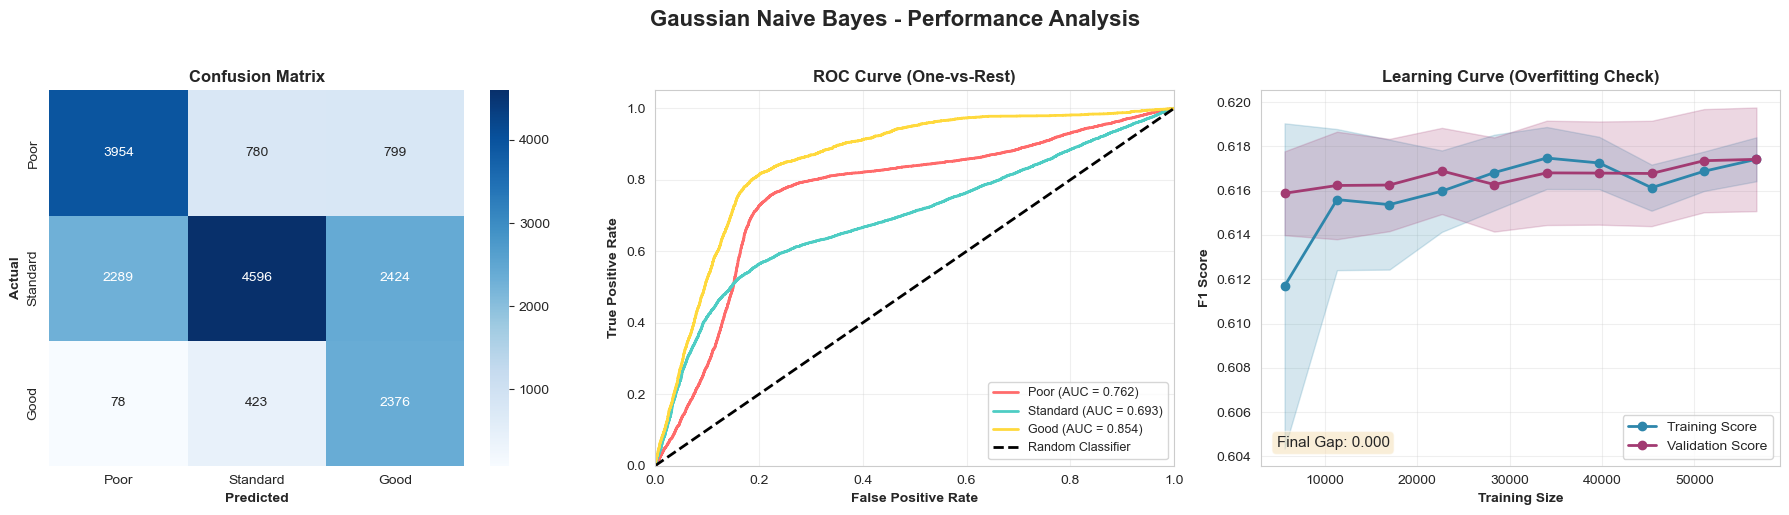

In [1015]:
nb_params = {'var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3]}
nb_results = train_and_evaluate(GaussianNB(), nb_params, 'Gaussian Naive Bayes')

## 11.3b Model 1b: Multinomial Naive Bayes (with MinMaxScaler)


Training: Multinomial Naive Bayes
Using MinMaxScaler data (non-negative features)
Fitting 11 folds for each of 5 candidates, totalling 55 fits

Best Parameters: {'alpha': 10.0}
Training Time: 0.66s
Training Accuracy: 0.5784 | Test Accuracy: 0.5773 | Gap: 0.0011
Training F1:       0.5610 | Test F1:       0.5593 | Gap: 0.0017
Overfitting Status: ✅ No significant overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.59      0.41      0.48      5533
    Standard       0.59      0.76      0.66      9309
        Good       0.49      0.30      0.37      2877

    accuracy                           0.58     17719
   macro avg       0.55      0.49      0.50     17719
weighted avg       0.57      0.58      0.56     17719


Best Parameters: {'alpha': 10.0}
Training Time: 0.66s
Training Accuracy: 0.5784 | Test Accuracy: 0.5773 | Gap: 0.0011
Training F1:       0.5610 | Test F1:       0.5593 | Gap: 0.0017
Overfitting Status: ✅ No significant 

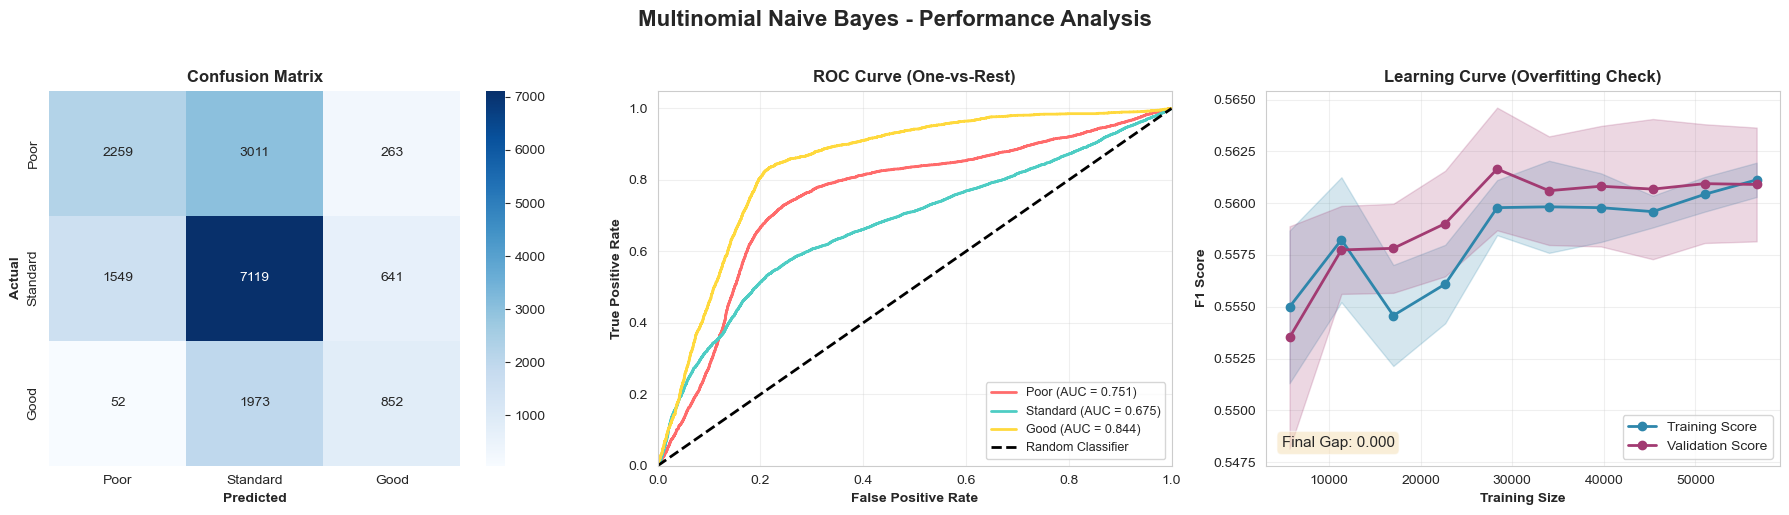

In [1021]:
mnb_params = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]} 
mnb_results = train_and_evaluate(MultinomialNB(), mnb_params, 'Multinomial Naive Bayes', use_minmax=True)

## 11.4 Model 2: Softmax Regression (Logistic Regression)


Training: Logistic Regression (Softmax)
Using RobustScaler data
Fitting 11 folds for each of 5 candidates, totalling 55 fits

Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'multi_class': 'multinomial', 'penalty': 'l2'}
Training Time: 4.50s
Training Accuracy: 0.6549 | Test Accuracy: 0.6532 | Gap: 0.0017
Training F1:       0.6582 | Test F1:       0.6567 | Gap: 0.0015
Overfitting Status: ✅ No significant overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.62      0.69      0.65      5533
    Standard       0.80      0.58      0.67      9309
        Good       0.49      0.82      0.61      2877

    accuracy                           0.65     17719
   macro avg       0.64      0.70      0.65     17719
weighted avg       0.69      0.65      0.66     17719


Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'multi_class': 'multinomial', 'penalty': 'l2'}
Training Time: 4.50s
Training Accuracy: 0.6549 | Test Accuracy

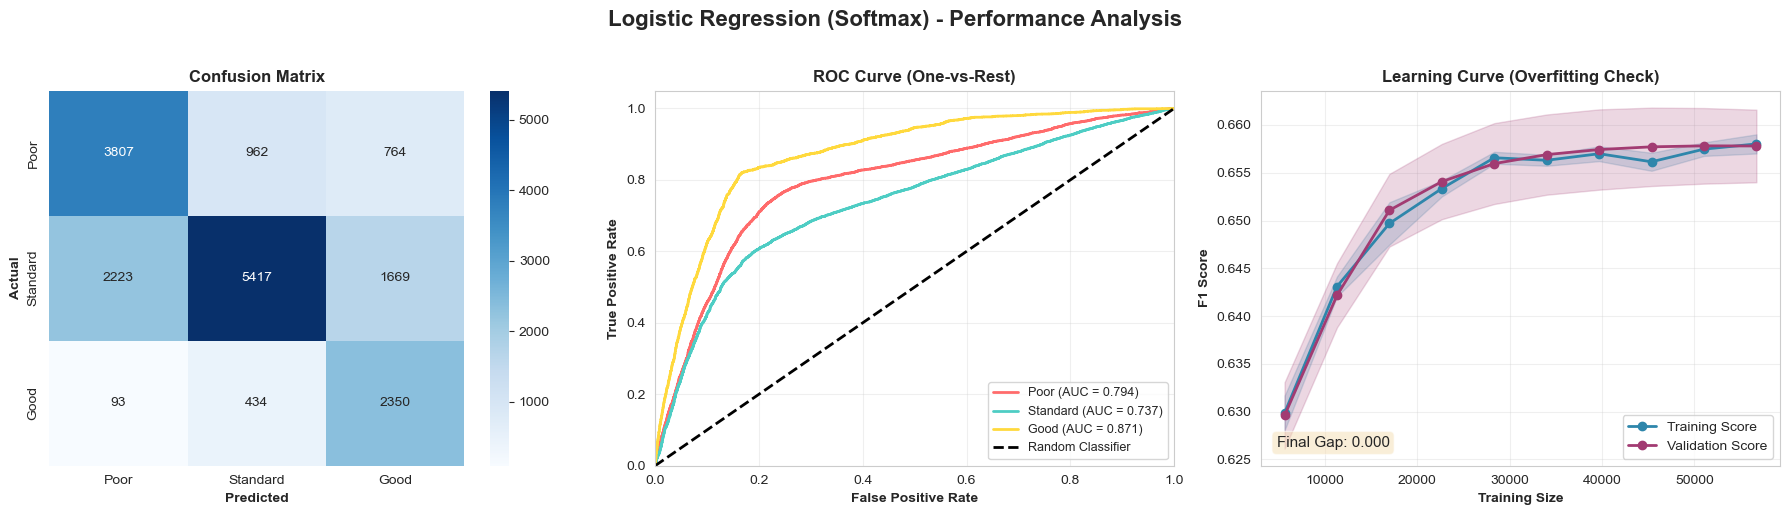

In [1022]:
lr_params = {
    'C': [0.001, 0.01, 0.05, 0.1, 1.0], 
    'penalty': ['l2'],
    'class_weight': ['balanced'],
    'multi_class': ['multinomial']
}
lr_results = train_and_evaluate(LogisticRegression(max_iter=1000), lr_params, 'Logistic Regression (Softmax)')

## 11.5 Model 3: Decision Tree


Training: Decision Tree
Using RobustScaler data
Fitting 11 folds for each of 64 candidates, totalling 704 fits

Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 20}
Training Time: 69.68s
Training Accuracy: 0.8353 | Test Accuracy: 0.7504 | Gap: 0.0849
Training F1:       0.8351 | Test F1:       0.7501 | Gap: 0.0850
Overfitting Status: 🟢 Mild overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.73      0.76      0.75      5533
    Standard       0.77      0.77      0.77      9309
        Good       0.70      0.66      0.68      2877

    accuracy                           0.75     17719
   macro avg       0.74      0.73      0.73     17719
weighted avg       0.75      0.75      0.75     17719


Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 20}
Training Time: 69.68s
Training Accu

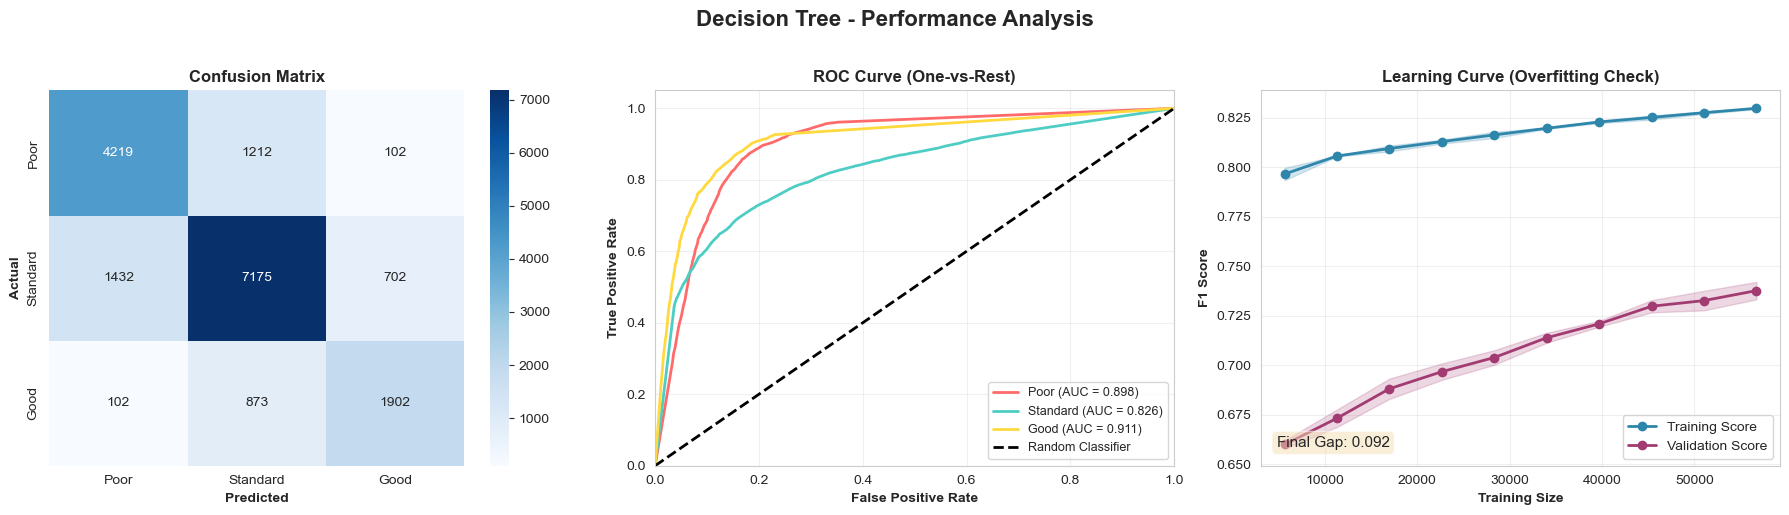

In [1024]:
dt_params = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [20, 50],
    'min_samples_leaf': [10, 20],
    'class_weight': ['balanced', None],
    'criterion': ['gini', 'entropy']
}
dt_results = train_and_evaluate(DecisionTreeClassifier(random_state=42), dt_params, 'Decision Tree')

### 11.5b Feature Importance

In [994]:
# ===== FEATURE IMPORTANCE ANALYSIS =====
best_dt_model = dt_results['Best_Estimator']
feature_importances = best_dt_model.feature_importances_
feature_names = X_train.columns

# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display top 20 features
print("\n📊 Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))


📊 Top 20 Most Important Features:
                Feature  Importance
       Outstanding_Debt    0.269324
             Credit_Mix    0.171258
          Interest_Rate    0.067606
     Credit_History_Age    0.064308
   Changed_Credit_Limit    0.061061
            Customer_ID    0.052817
    Delay_from_due_date    0.049947
  Monthly_Inhand_Salary    0.043659
          Annual_Income    0.037772
        Num_Credit_Card    0.031301
Amount_invested_monthly    0.030513
 Num_of_Delayed_Payment    0.028439
   Num_Credit_Inquiries    0.025762
      Num_Bank_Accounts    0.022138
            Num_of_Loan    0.017314
       Home Equity Loan    0.007608
           Student Loan    0.007115
    Credit-Builder Loan    0.005636
            Payday Loan    0.005458
  Payment_of_Min_Amount    0.000964


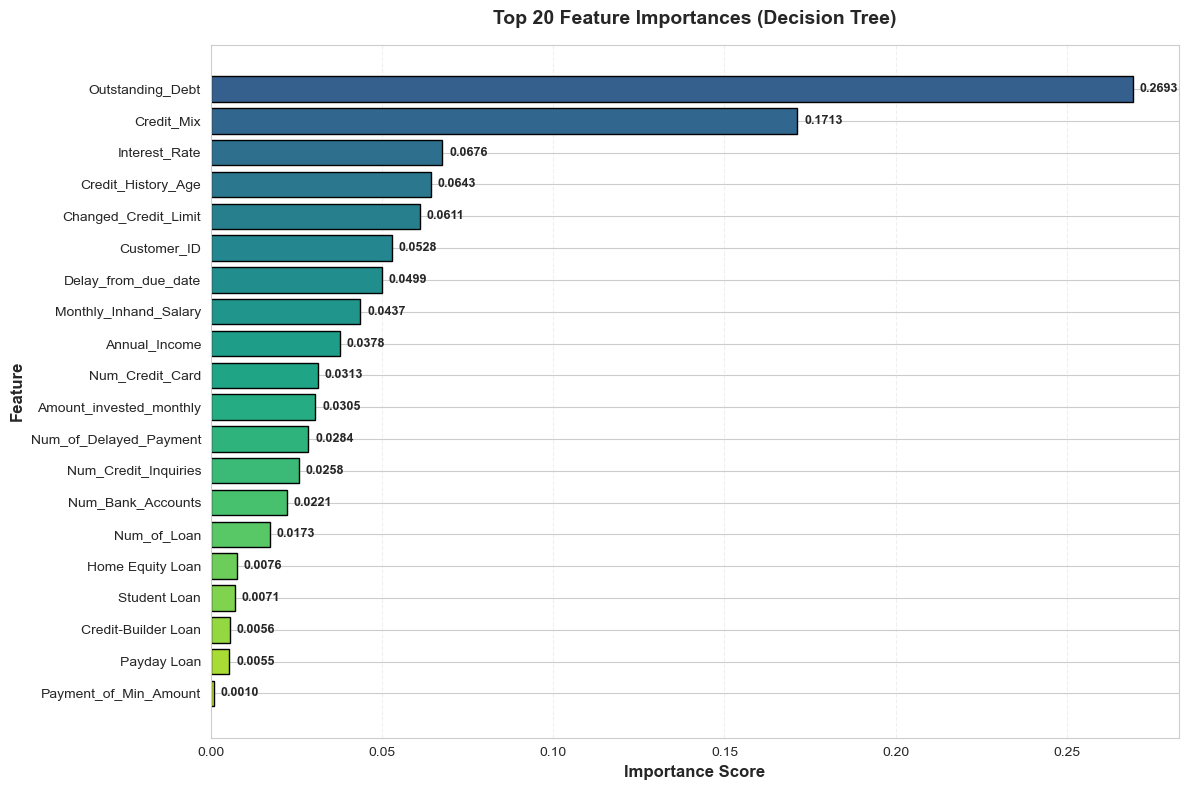

In [995]:
# ===== FEATURE IMPORTANCE BAR PLOT =====
plt.figure(figsize=(12, 8))
top_n = 20  # Show top 20 features
top_features = importance_df.head(top_n)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
bars = plt.barh(top_features['Feature'], top_features['Importance'], 
                color=colors, edgecolor='black', linewidth=1)

plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Feature Importances (Decision Tree)', 
          fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, value in zip(bars, top_features['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{value:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

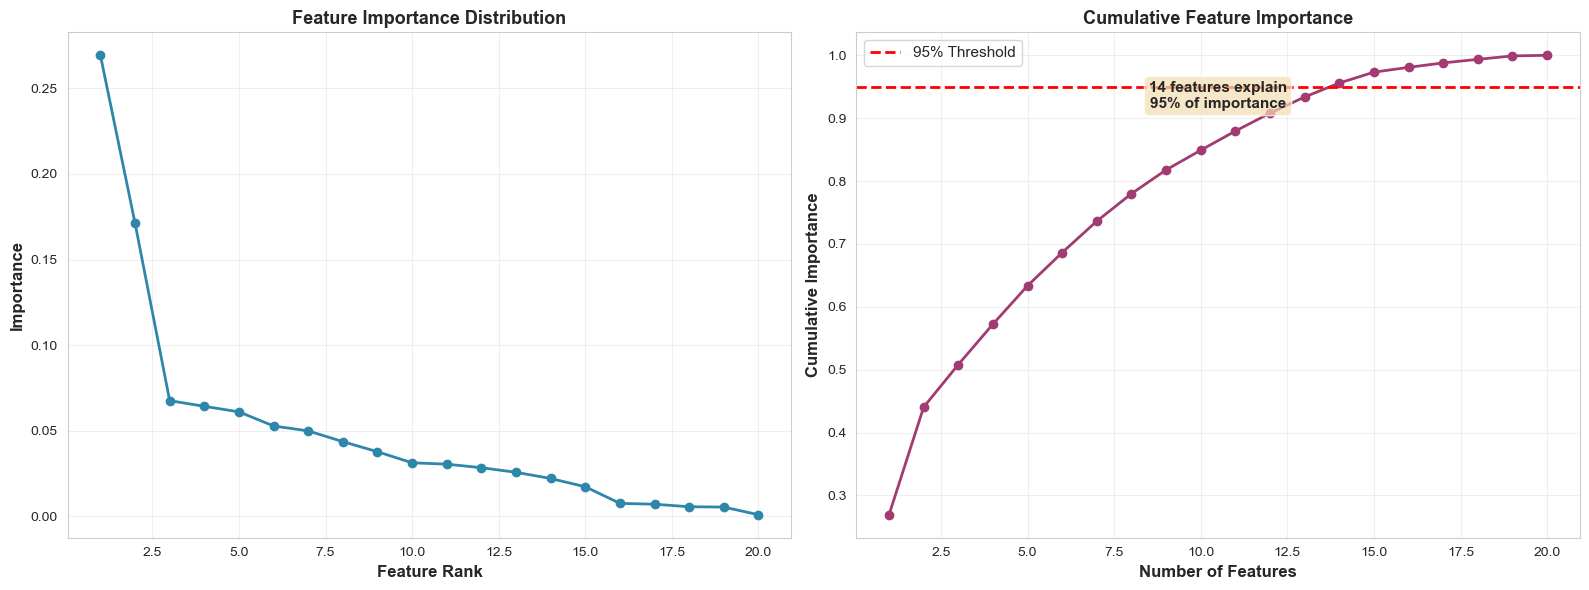


💡 Insight: 14 features explain 95% of the model's decisions
📊 Total features used: 20
🎯 Feature reduction potential: 6 features could be removed


In [996]:
# ===== 4. CUMULATIVE IMPORTANCE PLOT =====
importance_df['Cumulative_Importance'] = importance_df['Importance'].cumsum()

# Reset index to ensure proper counting
importance_df_reset = importance_df.reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Individual importance
ax1.plot(range(1, len(importance_df_reset) + 1), importance_df_reset['Importance'], 
         'o-', color='#2E86AB', linewidth=2, markersize=6)
ax1.set_xlabel('Feature Rank', fontsize=12, fontweight='bold')
ax1.set_ylabel('Importance', fontsize=12, fontweight='bold')
ax1.set_title('Feature Importance Distribution', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

# Right: Cumulative importance
ax2.plot(range(1, len(importance_df_reset) + 1), importance_df_reset['Cumulative_Importance'], 
         'o-', color='#A23B72', linewidth=2, markersize=6)
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
ax2.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# ✅ CORRECTED: Find how many features explain 95% of importance
features_for_95 = (importance_df_reset['Cumulative_Importance'] >= 0.95).idxmax() + 1

ax2.text(0.5, 0.85, f'{features_for_95} features explain\n95% of importance',
         transform=ax2.transAxes, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
         ha='center')

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: {features_for_95} features explain 95% of the model's decisions")
print(f"📊 Total features used: {len(feature_names)}")
print(f"🎯 Feature reduction potential: {len(feature_names) - features_for_95} features could be removed")

## 11.6 Model 4: Random Forest


Training: Random Forest
Using RobustScaler data
Fitting 11 folds for each of 24 candidates, totalling 264 fits

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Training Time: 313.24s
Training Accuracy: 0.9411 | Test Accuracy: 0.8094 | Gap: 0.1317
Training F1:       0.9411 | Test F1:       0.8092 | Gap: 0.1319
Overfitting Status: 🟡 Moderate overfitting
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Poor       0.79      0.85      0.82      5533
    Standard       0.83      0.81      0.82      9309
        Good       0.78      0.74      0.76      2877

    accuracy                           0.81     17719
   macro avg       0.80      0.80      0.80     17719
weighted avg       0.81      0.81      0.81     17719


Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Training Time: 313.24s
Training Accuracy: 0.9411 | Test Accuracy: 0.8094 | Gap

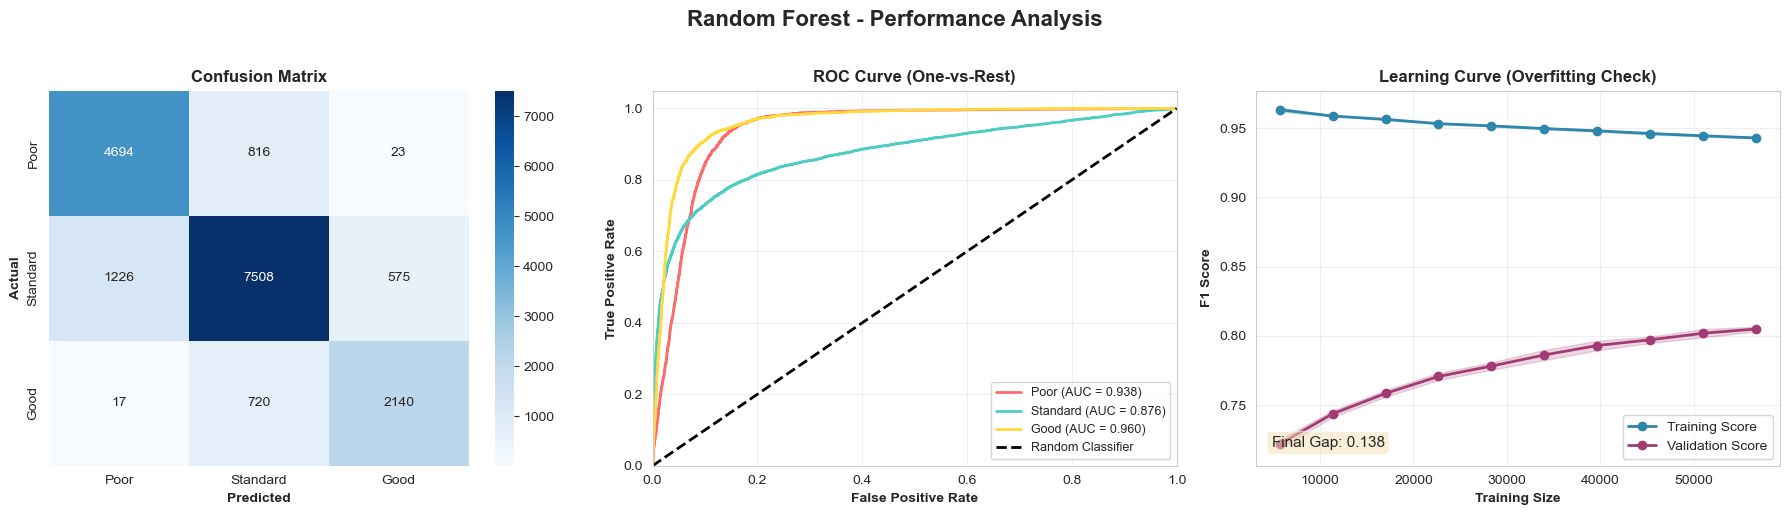

In [1025]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [2, 5, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_results = train_and_evaluate(RandomForestClassifier(random_state=42), rf_params, 'Random Forest')

## 11.7 Final Model Comparison

In [1028]:
results_df = pd.DataFrame([
    {
        'Model': nb_results['Model'],
        'Accuracy': nb_results['Accuracy'],
        'Precision': nb_results['Precision'],
        'Recall': nb_results['Recall'],
        'F1_Score': nb_results['F1_Score'],
        'Training_Time': nb_results['Training_Time'],
        'Train_Accuracy': nb_results['Train_Accuracy'],
        'Train_F1': nb_results['Train_F1'],
        'Accuracy_Gap': nb_results['Accuracy_Gap'],
        'F1_Gap': nb_results['F1_Gap'],
        'Overfitting_Status': nb_results['Overfitting_Status']
    },
    {
        'Model': mnb_results['Model'],
        'Accuracy': mnb_results['Accuracy'],
        'Precision': mnb_results['Precision'],
        'Recall': mnb_results['Recall'],
        'F1_Score': mnb_results['F1_Score'],
        'Training_Time': mnb_results['Training_Time'],
        'Train_Accuracy': mnb_results['Train_Accuracy'],
        'Train_F1': mnb_results['Train_F1'],
        'Accuracy_Gap': mnb_results['Accuracy_Gap'],
        'F1_Gap': mnb_results['F1_Gap'],
        'Overfitting_Status': mnb_results['Overfitting_Status']
    },
    {
        'Model': lr_results['Model'],
        'Accuracy': lr_results['Accuracy'],
        'Precision': lr_results['Precision'],
        'Recall': lr_results['Recall'],
        'F1_Score': lr_results['F1_Score'],
        'Training_Time': lr_results['Training_Time'],
        'Train_Accuracy': lr_results['Train_Accuracy'],
        'Train_F1': lr_results['Train_F1'],
        'Accuracy_Gap': lr_results['Accuracy_Gap'],
        'F1_Gap': lr_results['F1_Gap'],
        'Overfitting_Status': lr_results['Overfitting_Status']
    },
    {
        'Model': dt_results['Model'],
        'Accuracy': dt_results['Accuracy'],
        'Precision': dt_results['Precision'],
        'Recall': dt_results['Recall'],
        'F1_Score': dt_results['F1_Score'],
        'Training_Time': dt_results['Training_Time'],
        'Train_Accuracy': dt_results['Train_Accuracy'],
        'Train_F1': dt_results['Train_F1'],
        'Accuracy_Gap': dt_results['Accuracy_Gap'],
        'F1_Gap': dt_results['F1_Gap'],
        'Overfitting_Status': dt_results['Overfitting_Status']
    },
    {
        'Model': rf_results['Model'],
        'Accuracy': rf_results['Accuracy'],
        'Precision': rf_results['Precision'],
        'Recall': rf_results['Recall'],
        'F1_Score': rf_results['F1_Score'],
        'Training_Time': rf_results['Training_Time'],
        'Train_Accuracy': rf_results['Train_Accuracy'],
        'Train_F1': rf_results['Train_F1'],
        'Accuracy_Gap': rf_results['Accuracy_Gap'],
        'F1_Gap': rf_results['F1_Gap'],
        'Overfitting_Status': rf_results['Overfitting_Status']
    }
])

print(results_df.to_string(index=False))

                        Model  Accuracy  Precision   Recall  F1_Score  Training_Time  Train_Accuracy  Train_F1  Accuracy_Gap    F1_Gap           Overfitting_Status
         Gaussian Naive Bayes  0.616626   0.680615 0.616626  0.618991       0.805335        0.615961  0.617604     -0.000665 -0.001387 ✅ No significant overfitting
      Multinomial Naive Bayes  0.577346   0.570549 0.577346  0.559262       0.656277        0.578443  0.560997      0.001097  0.001735 ✅ No significant overfitting
Logistic Regression (Softmax)  0.653197   0.691645 0.653197  0.656652       4.504823        0.654876  0.658159      0.001678  0.001507 ✅ No significant overfitting
                Decision Tree  0.750381   0.750202 0.750381  0.750096      69.683895        0.835325  0.835110      0.084944  0.085014           🟢 Mild overfitting
                Random Forest  0.809414   0.809934 0.809414  0.809191     313.243486        0.941078  0.941069      0.131664  0.131878       🟡 Moderate overfitting


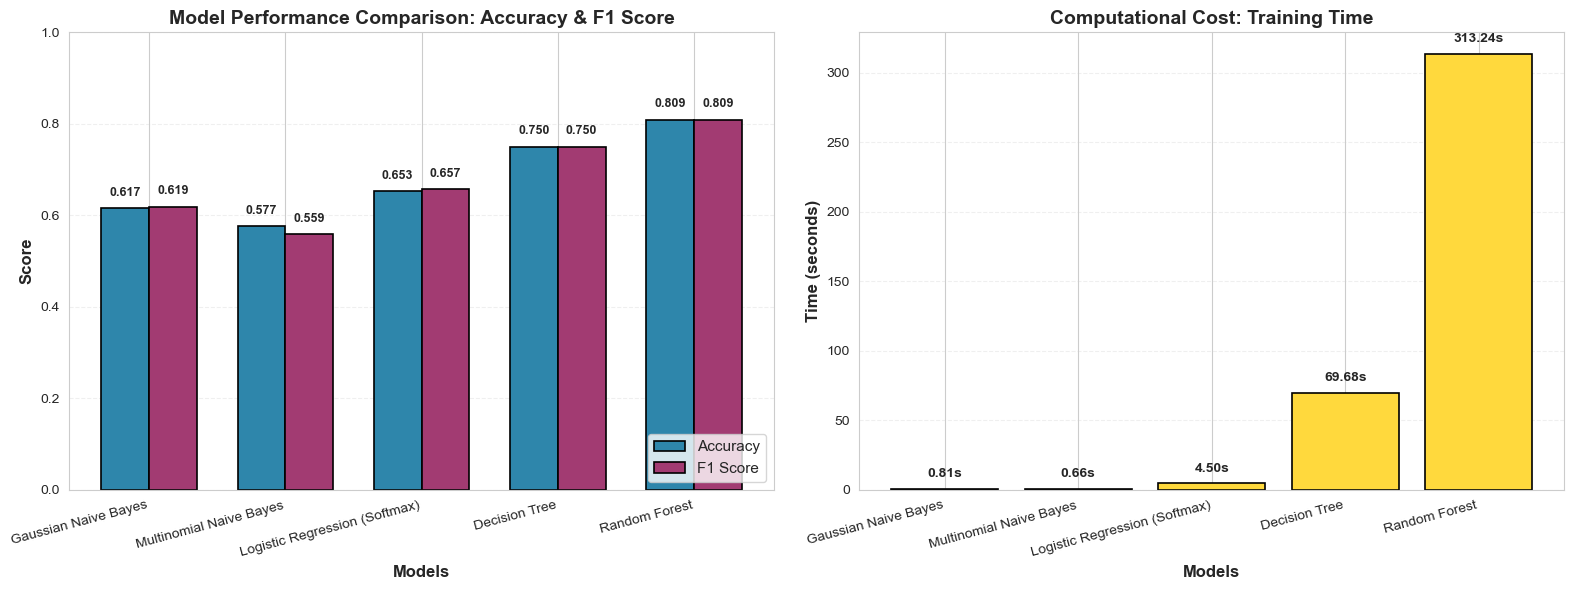

In [1033]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(results_df))
width = 0.35

axes[0].bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', 
            color='#2E86AB', edgecolor='black', linewidth=1.2)
axes[0].bar(x + width/2, results_df['F1_Score'], width, label='F1 Score', 
            color='#A23B72', edgecolor='black', linewidth=1.2)

axes[0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance Comparison: Accuracy & F1 Score', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 1])

for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')
for i, v in enumerate(results_df['F1_Score']):
    axes[0].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

bars = axes[1].bar(results_df['Model'], results_df['Training_Time'], 
                   color='#FFD93D', edgecolor='black', linewidth=1.2)
axes[1].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Computational Cost: Training Time', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + max(results_df['Training_Time'])*0.02,
                f'{height:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

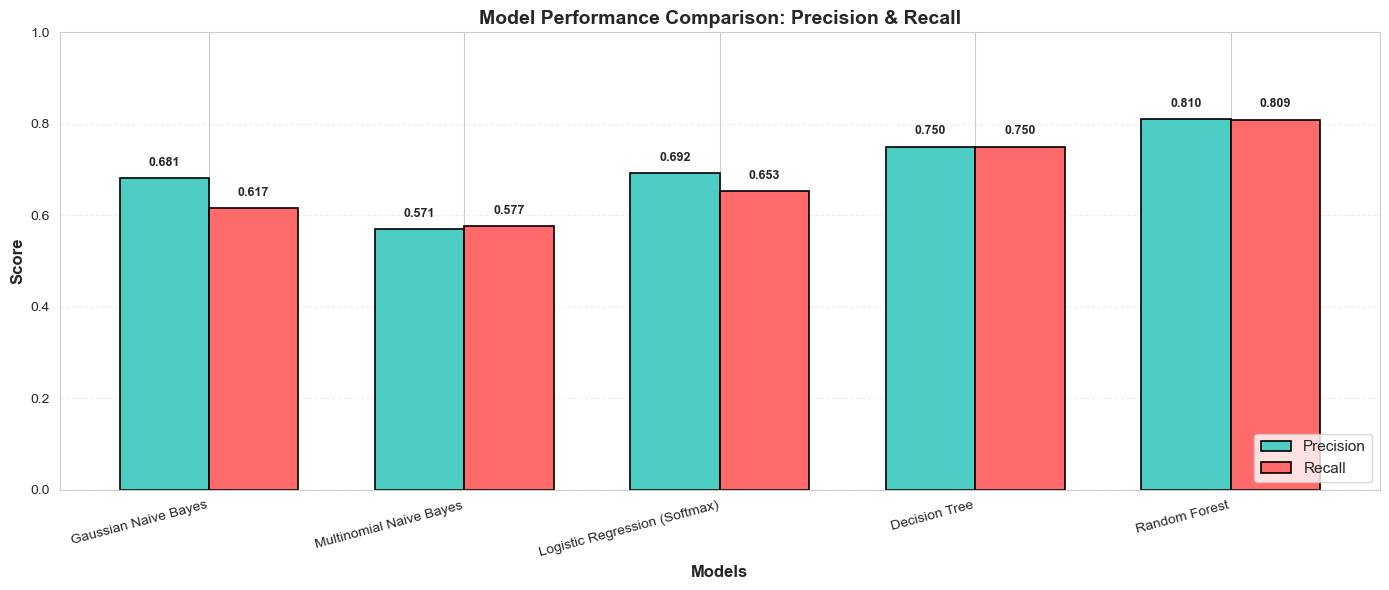


📊 Precision & Recall Summary:
Gaussian Naive Bayes           | Precision: 0.6806 | Recall: 0.6166
Multinomial Naive Bayes        | Precision: 0.5705 | Recall: 0.5773
Logistic Regression (Softmax)  | Precision: 0.6916 | Recall: 0.6532
Decision Tree                  | Precision: 0.7502 | Recall: 0.7504
Random Forest                  | Precision: 0.8099 | Recall: 0.8094


In [1039]:
# Create merged bar plot for Precision and Recall comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_df))
width = 0.35

# Plot both Precision and Recall side-by-side
bars1 = ax.bar(x - width/2, results_df['Precision'], width, label='Precision', 
               color='#4ECDC4', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, results_df['Recall'], width, label='Recall', 
               color='#FF6B6B', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Precision & Recall', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1])

# Add value labels on bars for Precision
for i, v in enumerate(results_df['Precision']):
    ax.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Add value labels on bars for Recall
for i, v in enumerate(results_df['Recall']):
    ax.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Precision & Recall Summary:")
print("="*70)
for idx, row in results_df.iterrows():
    print(f"{row['Model']:30s} | Precision: {row['Precision']:.4f} | Recall: {row['Recall']:.4f}")

## 11.8 Best Model Summary

In [1000]:
best_model_idx = results_df['F1_Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1_Score']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']

print("\n" + "="*70)
print("BEST MODEL IDENTIFIED")
print("="*70)
print(f"\n🏆 Winner: {best_model_name}")
print(f"\n📊 Performance Metrics:")
print(f"   • Accuracy:  {best_accuracy:.4f}")
print(f"   • F1 Score:  {best_f1:.4f}")
print(f"   • Precision: {results_df.loc[best_model_idx, 'Precision']:.4f}")
print(f"   • Recall:    {results_df.loc[best_model_idx, 'Recall']:.4f}")
print(f"\n⏱️  Training Time: {results_df.loc[best_model_idx, 'Training_Time']:.2f}s")
print("\n" + "="*70)
print("✅ MODELING COMPLETE - READY FOR DEPLOYMENT")
print("="*70)


BEST MODEL IDENTIFIED

🏆 Winner: Decision Tree

📊 Performance Metrics:
   • Accuracy:  0.7498
   • F1 Score:  0.7495
   • Precision: 0.7494
   • Recall:    0.7498

⏱️  Training Time: 25.76s

✅ MODELING COMPLETE - READY FOR DEPLOYMENT
